# Необходимые функции и импорты библиотек

In [ ]:
import os
os.chdir('E:/GitHubProjects/autolabeling_time_series_data/')

from typing import Literal, Callable
import numpy as np
import pandas as pd
pd.set_option('display.max_colwidth', 150)
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


from src.clustering import Sklearn_kmeans_model, BIRCH_model, DBSCAN_model,AC_model
from src.clustering.Clustering_scorer import Clustering_scorer
from src.feature_extraction.manual_methods.TS_feature_extractor import Feature_extraction_method, Feature_extractor_pipeline
from src.feature_extraction.manual_methods.manual_feature_extraction import (
    no_fe,
    tsa_detrend, 
    statistical_features,
    paa_features,
    signal_peaks_features,
    stft_features,
    dft_components,
    dft_signal,
    dft_approximation,
    dwt_features,
    dwt_signal, 
    stl_trend,
    stl_seasonal,
    stl_noise,
    stl_features
)

from src.feature_extraction.manual_methods.trend_fe_algo import *


from src.utils import plot_series
from scripts.synthetic_generators import *

In [2]:
# Формирование сетки параметров

def get_dataset_inxs(grid, noise_level=[], sample_size=[], shifts=[], ts_length=[], value_scale=[]):
    """
    """
    inxs = []
    for inx, params in enumerate(grid):
        # print('*'*100)
        # print(inx, params)
        # print()
        # print(params['noise_level'] in noise_level and not inx_found)
        noise_cnt = False
        sample_size_cnt = False
        shifts_cnt = False 
        ts_length_cnt = False
        value_scale_cnt = False
        
        if params['noise_level'] in noise_level:
            noise_cnt = True
        # print(params['sample_size'] in sample_size and not inx_found)
        if params['sample_size'] in sample_size:
            sample_size_cnt = True
        # print(params['shifts'] in shifts and not inx_found)
        if params['shifts'] in shifts:
            shifts_cnt = True
        # print(params['ts_length'] in ts_length and not inx_found)
        if params['ts_length'] in ts_length:
            ts_length_cnt = True
        # print(params['value_scale'] in value_scale and not inx_found)
        if params['value_scale'] in value_scale:
            value_scale_cnt = True
        
        if noise_cnt and sample_size_cnt and shifts_cnt and ts_length_cnt and value_scale_cnt:
            inxs.append(inx)
        # print()
        # print(inxs)
    
    return inxs

In [3]:
# функции по изменению файла конфигурации для исключения ошибок и ускорения тестирования на синтетике

def adapt_kmeans(config, dist_params):
    param_grid = config['param_grid']

    if 'n_clusters' in param_grid:
        base = param_grid['n_clusters']
        n_clusters_base = dist_params.get('n_cluster', 2)
        low = max(base.get('low', 2), n_clusters_base - 2)
        high = n_clusters_base + 2

        param_grid['n_clusters']['low'] = low
        param_grid['n_clusters']['high'] = high

    return config


def adapt_dbscan(config, dist_params):
    param_grid = config['param_grid']

    if 'min_samples' in param_grid:
        base = param_grid['min_samples']
        sample_size = dist_params.get('sample_size', 100)
        new_low = max(base.get('low', 1), int(sample_size * 0.01))
        new_high = max(new_low + 5, int(sample_size * 0.1))

        param_grid['min_samples']['low'] = new_low
        param_grid['min_samples']['high'] = new_high

    if 'eps' in param_grid:
        base = param_grid['eps']
        ts_length = dist_params.get('ts_length', 100)
        noise_factor = 1.0 if ts_length < 500 else 1.5 if ts_length < 2000 else 2.0
        new_high = base.get('high', 20) * noise_factor

        param_grid['eps']['high'] = round(float(new_high), 2)
    
    return config


def adapt_birch(config, dist_params):
    param_grid = config['param_grid']

    if 'n_clusters' in param_grid:
        base = param_grid['n_clusters']
        low = base.get('low', 2)
        high = dist_params.get('n_cluster', 2) + 2

        param_grid['n_clusters']['low'] = low
        param_grid['n_clusters']['high'] = high

    if 'threshold' in param_grid:
        base = param_grid['threshold']
        value_scale = dist_params.get('value_scale', [0, 1])
        scale_range = value_scale[1] - value_scale[0]
        new_low = max(base.get('low', 0.1), scale_range * 0.01)
        new_high = max(new_low + 1, scale_range * 0.1)

        param_grid['threshold']['low'] = round(float(new_low), 2)
        param_grid['threshold']['high'] = round(float(new_high), 2)
    
    return config


def adapt_agglomerative(config, dist_params):
    return adapt_kmeans(config, dist_params)


def get_model(model_name:Literal['dbscan', 'birch', 'sklearn_kmeans', 'agglomerative'], X, y, dist_params:dict=None, model_config_path:str='configs/parameters_search/'):
    
    config = load_config_file(f'{model_config_path}/{model_name}.yaml')
    
    if model_name == 'dbscan':
        model = DBSCAN_model()
        if dist_params is not None:
            config = adapt_dbscan(config, dist_params)
        
    if model_name == 'birch':
        model = BIRCH_model()
        if dist_params is not None:
            config = adapt_birch(config, dist_params)
            
    if model_name == 'sklearn_kmeans':
        model = Sklearn_kmeans_model()
        if dist_params is not None:
            config = adapt_kmeans(config, dist_params)
        
    if model_name == 'agglomerative':
        model = AC_model()
        if dist_params is not None:
            config = adapt_agglomerative(config, dist_params)

    scorer = Clustering_scorer(
        metrics=None,
        debug=True 
        )

    result_df = scorer.grid_search(model=model, X=X, y_true=y, model_name=model_name, param_grid=config)

    return result_df

def get_result(X, y, segments_grid, fe_pipeline, dist_params, model_config_path):
    
    res_df = pd.DataFrame()
    
    for n_segment in segments_grid:
        if n_segment == 1:
            use_segm = False
        features = fe_pipeline.batch_extract(X, use_segmentation=use_segm, n_segments=n_segment, verbose=False)

        for (X_train, fe_params) in features:
            y_train = np.asarray(y)
            fe_params = fe_params

            for model_name in ['dbscan', 'birch', 'sklearn_kmeans', 'agglomerative']:
                model_df = get_model(model_name, X_train, y_train, dist_params, model_config_path)
                model_df['model_name'] = model_name
                model_df['fe_method']= list(fe_params.keys())[0]
                model_df['fe_params']= '__'.join(['_'.join([str(k), str(v)]) for k,v in list(fe_params.values())[0].items()])
                model_df['segment'] = n_segment
                
                res_df = pd.concat([res_df, model_df])
    
    return res_df

In [4]:
def visualize_clusters(X, y, save_path):
    for val in np.unique(y):
        plot_series(X[y == val].tolist(), show_legend=False, plot_title=f'Cluster {val}', save_path=f"{save_path}/Cluster {val}.png")


def visualize_latent_space(train_latents, train_labels, model_save_path):
    """
    Визуализация латентного пространства с помощью t-SNE.
    Объединяет train и val для проецирования, но различает их на графике.
    """
    # Применяем t-SNE ко всем данным сразу
    tsne = TSNE(n_components=2, random_state=42, init='random', perplexity=30)
    latents_2d = tsne.fit_transform(train_latents)

    # Визуализация
    plt.figure(figsize=(12, 8))

    # Точки из train
    scatter_train = plt.scatter(latents_2d[:, 0], latents_2d[:, 1], 
                                c=train_labels, cmap='tab10', s=60, 
                                label='Train', edgecolor='k', alpha=0.7)

    # Легенда
    unique_labels = np.unique(train_labels)
    handles, _ = scatter_train.legend_elements(prop="colors", num=len(unique_labels))
    plt.legend(handles, unique_labels, title="Classes")

    plt.title("Latent Space Visualization (t-SNE)")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.grid(True)
    plt.tight_layout()
    if model_save_path is not None:
        plt.savefig(model_save_path)
        plt.close()
    else:
        plt.show()
        
    return latents_2d

# Анализ трендов 

## Линейный тренд

In [5]:
full_grid = create_dist_params('configs/conditions/characteristic_grid.yaml', False)

full_grid[0]

{'noise_level': [0, 0.01],
 'sample_size': 50,
 'shifts': 0,
 'ts_length': 101,
 'value_scale': [0, 1]}

In [6]:
gen_dt_index = get_dataset_inxs(full_grid, [[0.01, 0.05], [0.1, 0.2]], [50, 200], [0, 1], [101, 1001], [[0,1]])

{'noise_level': [0.01, 0.05], 'sample_size': 50, 'shifts': 1, 'ts_length': 101, 'value_scale': [0, 1], 'n_cluster': 1}


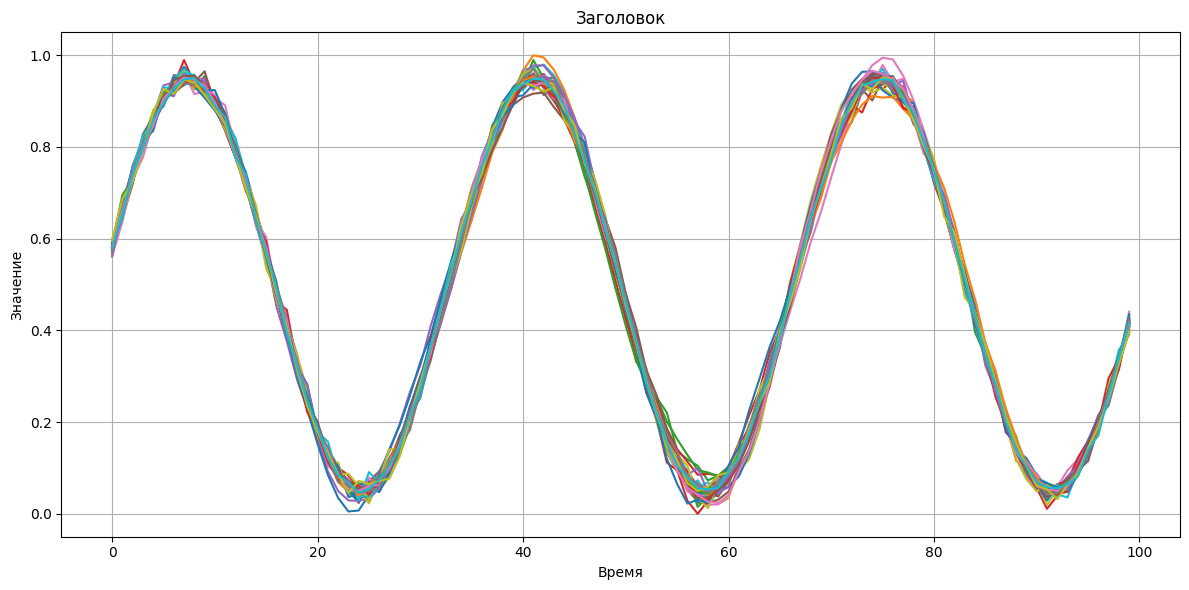

(50, 100)
0 - 1.00


In [113]:
# выбор параметров
dist_params1 = full_grid[0]
print(dist_params1)
dist_params1['n_cluster'] = 1
dist_params1['shifts'] = 1
dist_params1['noise_level'] = [0.01, 0.05]
# dist_params1['sample_size'] = 50
dist_params1['value_scale'] = [0, 1]

np.random.seed(21)
# генерация выборки
# generator = linear_generator(dist_params1['n_cluster'], dist_params1['ts_length'])
generator = sin_wave_generator(dist_params1['n_cluster'], dist_params1['ts_length'])
generator.config['frequency_d'] = 3
harmonic_shift = harmonic_shift_generator(dist_params1['ts_length'])
sample_seasonal2, labels_seasonal2 = create_dist(generator, dist_params1, harmonic_shift, True, None)
sample_stats(sample_seasonal2, labels_seasonal2)

# обучение без применения признаков
segments_grid = range(1,6,2)

sample_name = f'{dist_params1['n_cluster']}_{dist_params1['shifts']}_{dist_params1['noise_level'][0]}_{dist_params1['value_scale'][0]}_{dist_params1['sample_size']}'

basic_path = 'data/Synthetic_data/sin_wave_dataset'

{'noise_level': [0.01, 0.05], 'sample_size': 50, 'shifts': 1, 'ts_length': 101, 'value_scale': [0, 1], 'n_cluster': 1}


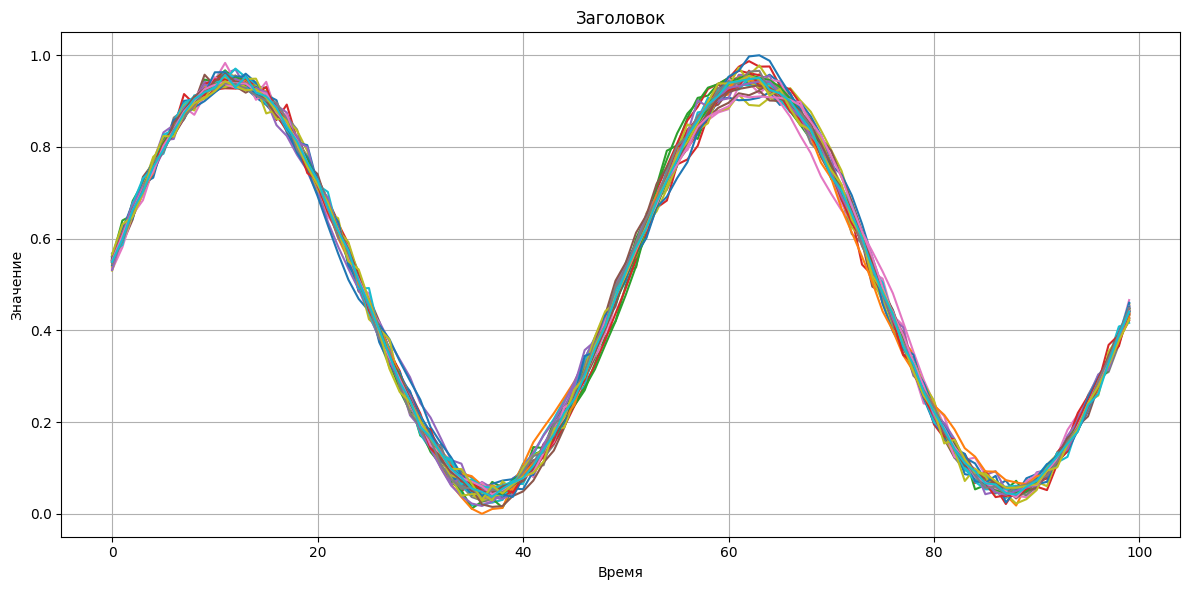

(50, 100)
0 - 1.00


In [114]:
# выбор параметров
dist_params1 = full_grid[0]
print(dist_params1)
dist_params1['n_cluster'] = 1
dist_params1['shifts'] = 1
dist_params1['noise_level'] = [0.01, 0.05]
# dist_params1['sample_size'] = 50
dist_params1['value_scale'] = [0, 1]

np.random.seed(21)
# генерация выборки
# generator = linear_generator(dist_params1['n_cluster'], dist_params1['ts_length'])
generator = sin_wave_generator(dist_params1['n_cluster'], dist_params1['ts_length'])
harmonic_shift = harmonic_shift_generator(dist_params1['ts_length'])
sample_seasonal, labels_seasonal = create_dist(generator, dist_params1, harmonic_shift, True, None)
sample_stats(sample_seasonal, labels_seasonal)

# обучение без применения признаков
segments_grid = range(1,6,2)

sample_name = f'{dist_params1['n_cluster']}_{dist_params1['shifts']}_{dist_params1['noise_level'][0]}_{dist_params1['value_scale'][0]}_{dist_params1['sample_size']}'

basic_path = 'data/Synthetic_data/sin_wave_dataset'

In [ ]:
no_fe_extractor = Feature_extraction_method(no_fe, load_config_file('configs/manual_fe/no_fe.yaml'))

baseline_pipeline = Feature_extractor_pipeline([no_fe_extractor])
nofe_res = get_result(sample_seasonal, labels_seasonal, [1], baseline_pipeline, dist_params1, 'configs/parameters_search/trend')
nofe_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/nofe_res_{sample_name}.xlsx")

# nofe_res.loc[nofe_res.metric=='f1'].sort_values('value', ascending=False).head(15)

{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [1, 3, 5]}


Grid Search:   0%|          | 0/15 [00:00<?, ?it/s]

Grid Search: 100%|██████████| 15/15 [00:00<00:00, 32.64it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 30], 'n_clusters': [2, 3, 4]}


Grid Search: 100%|██████████| 30/30 [00:00<00:00, 76.74it/s]


{'n_clusters': [2, 3, 4], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


Grid Search:  69%|██████▉   | 25/36 [00:01<00:00, 16.30it/s]


KeyboardInterrupt: 

In [ ]:
methods = [
    Feature_extraction_method(dft_approximation, load_config_file('configs/manual_fe/dft_approximation.yaml'))
]

dft_apr_pipeline = Feature_extractor_pipeline(methods)
dft_apr_res = get_result(sample_seasonal, labels_seasonal, range(1,2), dft_apr_pipeline, dist_params1, 'configs/parameters_search/')
dft_apr_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/dft_apr_res_{sample_name}.xlsx")

{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 68.01it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


Grid Search: 100%|██████████| 550/550 [00:06<00:00, 86.29it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 550/550 [00:06<00:00, 87.54it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 33.40it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 116.04it/s]


In [ ]:
methods = [
    Feature_extraction_method(dft_components, load_config_file('configs/manual_fe/dft_components.yaml'))
]

dft_comp_pipeline = Feature_extractor_pipeline(methods)
dft_comp_res = get_result(sample_seasonal, labels_seasonal, range(1,2), dft_comp_pipeline, dist_params1, 'configs/parameters_search/')
dft_comp_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/dft_comp_res_{sample_name}.xlsx")

{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 139.03it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


Grid Search: 100%|██████████| 550/550 [00:05<00:00, 95.36it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 550/550 [00:06<00:00, 85.45it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 34.07it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 112.11it/s]


In [ ]:
methods = [
    Feature_extraction_method(dft_signal, load_config_file('configs/manual_fe/dft_signal.yaml'))
]

dft_sig_pipeline = Feature_extractor_pipeline(methods)
dft_sig_res = get_result(sample_seasonal, labels_seasonal, range(1,2), dft_sig_pipeline, dist_params1, 'configs/parameters_search/')
dft_sig_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/dft_sig_res_{sample_name}.xlsx")

{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 62.88it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


Grid Search: 100%|██████████| 550/550 [00:06<00:00, 90.19it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 550/550 [00:06<00:00, 91.22it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 34.53it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 114.25it/s]


In [ ]:
methods = [
    Feature_extraction_method(extract_acf_statistics, load_config_file('configs/manual_fe/trend/acf_statistics.yaml'))
]

acf_pipeline = Feature_extractor_pipeline(methods)
acf_res = get_result(sample_seasonal, labels_seasonal, range(1,2), acf_pipeline, dist_params1, 'configs/parameters_search/trend')
acf_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/acf_res_{sample_name}.xlsx")

# acf_res.loc[acf_res.metric=='f1'].sort_values('value', ascending=False).head(15)

{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [1, 3, 5]}


Grid Search: 100%|██████████| 15/15 [00:00<00:00, 148.97it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 30], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


Grid Search: 100%|██████████| 110/110 [00:00<00:00, 127.80it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 110/110 [00:01<00:00, 90.81it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:02<00:00, 25.49it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 103.95it/s]


In [ ]:
methods = [
    Feature_extraction_method(dwt_features, load_config_file('configs/manual_fe/dwt_features.yaml'))
]

dwt_feat_pipeline = Feature_extractor_pipeline(methods)
dwt_feat_res = get_result(sample_seasonal, labels_seasonal, range(1,2), dwt_feat_pipeline, dist_params1, 'configs/parameters_search')
dwt_feat_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/dwt_feat_res_{sample_name}.xlsx")

# acf_res.loc[acf_res.metric=='f1'].sort_values('value', ascending=False).head(15)

{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 152.07it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


Grid Search: 100%|██████████| 550/550 [00:04<00:00, 134.98it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 550/550 [00:05<00:00, 106.36it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 34.95it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 114.63it/s]


In [ ]:
methods = [
    Feature_extraction_method(dwt_signal, load_config_file('configs/manual_fe/dwt_signal.yaml'))
]

dwt_sig_pipeline = Feature_extractor_pipeline(methods)
dwt_sig_res = get_result(sample_seasonal, labels_seasonal, range(1,2), dwt_sig_pipeline, dist_params1, 'configs/parameters_search')
dwt_sig_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/dwt_sig_res_{sample_name}.xlsx")

# acf_res.loc[acf_res.metric=='f1'].sort_values('value', ascending=False).head(15)

{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 64.90it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


Grid Search: 100%|██████████| 550/550 [00:06<00:00, 86.95it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 550/550 [00:06<00:00, 85.52it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 33.34it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 112.35it/s]


In [ ]:
methods = [
    Feature_extraction_method(signal_peaks_features, load_config_file('configs/manual_fe/signal_peaks.yaml'))
]

sig_peaks_pipeline = Feature_extractor_pipeline(methods)
sig_peaks_res = get_result(sample_seasonal, labels_seasonal, range(1,2), sig_peaks_pipeline, dist_params1, 'configs/parameters_search')
sig_peaks_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/sig_peaks_res_{sample_name}.xlsx")


{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 85.46it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


Grid Search: 100%|██████████| 550/550 [00:06<00:00, 82.99it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 31.10it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 106.62it/s]


In [ ]:
methods = [
    Feature_extraction_method(stl_seasonal, load_config_file('configs/manual_fe/stl_decomposition.yaml'))
]

stl_seas_pipeline = Feature_extractor_pipeline(methods)
stl_seas_res = get_result(sample_seasonal, labels_seasonal, range(1,5), stl_seas_pipeline, dist_params1, 'configs/parameters_search')
stl_seas_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/stl_seas_res_{sample_name}.xlsx")


{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 48.14it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


Grid Search: 100%|██████████| 550/550 [00:04<00:00, 124.30it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 550/550 [00:06<00:00, 87.16it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 33.24it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 109.58it/s]


In [164]:
def get_top3(df, metric_name='ari'):

    return [df.loc[(df.model_name == name)&(df.metric == metric_name), ['value']].sort_values('value', ascending=False)[:3].mean().round(2).item() for name in ['dbscan', 'birch', 'sklearn_kmeans', 'agglomerative']]


def clustering_table(name, metric_name):
    return pd.DataFrame([get_top3(nofe_res, metric_name), get_top3(dft_apr_res, metric_name), get_top3(dft_comp_res, metric_name), get_top3(dft_sig_res, metric_name), get_top3(acf_res, metric_name), get_top3(dwt_feat_res, metric_name), get_top3(dwt_sig_res, metric_name), get_top3(sig_peaks_res, metric_name), get_top3(stl_seas_res, metric_name)], columns=['dbscan', 'birch', 'kmeans', 'agglomerative'], index = ['no', 'dft_approximation', 'dft_components', 'dft_signal', 'acf_features', 'dwt_features', 'dwt_signal', 'signal_peaks_features', 'stl_seasonal']).to_excel(f'{basic_path}/{metric_name}_clustering_{name}.xlsx')

def get_top5(df):
    return [df.loc[(df.metric == metric_name), ['value']].sort_values('value', ascending=False)[:5].mean().round(2).item() for metric_name in ['ari', 'nmi', 'silhouette', 'f1']]

def evaluation_table(name):
    return pd.DataFrame([get_top5(nofe_res), get_top5(dft_apr_res), get_top5(dft_comp_res), get_top5(dft_sig_res), get_top5(acf_res), get_top5(dwt_feat_res), get_top5(dwt_sig_res), get_top5(sig_peaks_res), get_top5(stl_seas_res)], columns=['ari', 'nmi', 'silhouette', 'f1'], index =['no', 'dft_approximation', 'dft_components', 'dft_signal', 'acf_features', 'dwt_features', 'dwt_signal', 'signal_peaks_features', 'stl_seasonal']).to_excel(f'{basic_path}/clustering_performance_{name}.xlsx')

def get_top5_segm(df, n_segm:int=1):
    return [df.loc[(df.metric == metric_name)&(df.segment ==n_segm), ['value']].sort_values('value', ascending=False)[:5].mean().round(2).item() for metric_name in ['ari', 'nmi', 'silhouette', 'f1']]

def evaluation_table_segm(name, segm):
    return pd.DataFrame([get_top5(nofe_res), get_top5_segm(dft_apr_res, segm), get_top5_segm(dft_comp_res, segm), get_top5_segm(dft_sig_res, segm), get_top5_segm(acf_res, segm), get_top5_segm(dwt_feat_res, segm), get_top5_segm(dwt_sig_res, segm), get_top5_segm(sig_peaks_res, segm), get_top5_segm(stl_seas_res, segm)], columns=['ari', 'nmi', 'silhouette', 'f1'], index =['no', 'dft_approximation', 'dft_components', 'dft_signal', 'acf_features', 'dwt_features', 'dwt_signal', 'signal_peaks_features', 'stl_seasonal']).to_excel(f'{basic_path}/{segm}_clustering_performance_{name}.xlsx')


for metric in ['ari', 'silhouette', 'f1']:
    clustering_table(sample_name, metric)
evaluation_table(sample_name)
for i in sig_peaks_res.segment.unique():
    evaluation_table_segm(sample_name, i)

{'noise_level': [0.01, 0.05], 'sample_size': 50, 'shifts': 1, 'ts_length': 101, 'value_scale': [0, 1], 'n_cluster': 5}


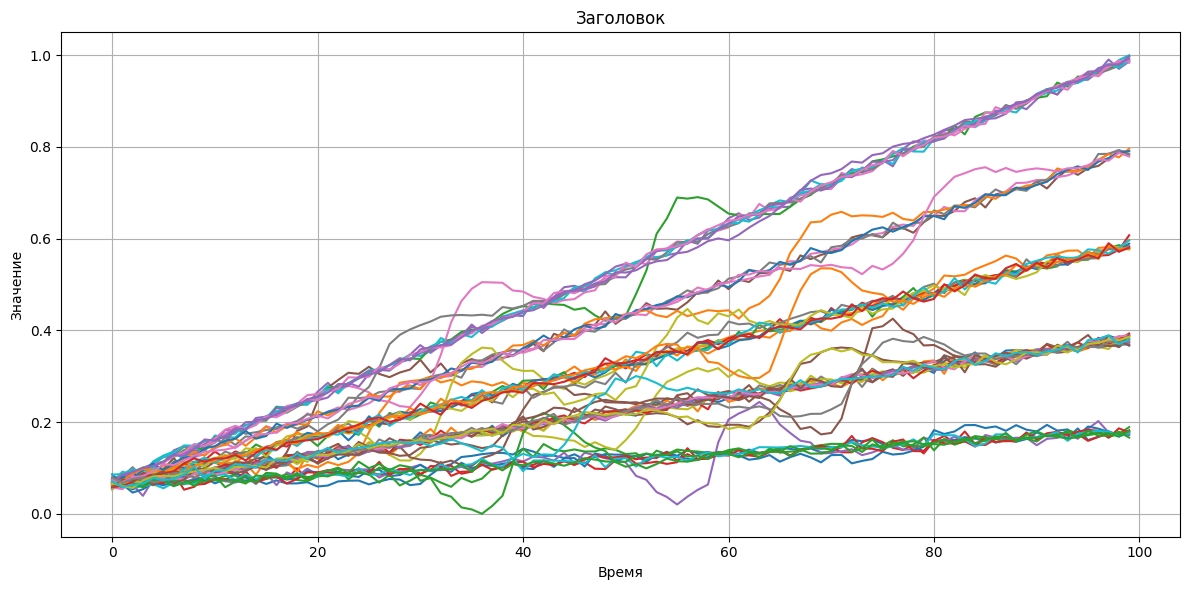

(50, 100)
0 - 0.18
1 - 0.30
2 - 0.22
3 - 0.12
4 - 0.18


In [144]:
# выбор параметров
dist_params1 = full_grid[0]
print(dist_params1)
dist_params1['n_cluster'] = 5
dist_params1['shifts'] = 1
dist_params1['noise_level'] = [0.05, 0.1]
# dist_params1['sample_size'] = 50
dist_params1['value_scale'] = [0, 1]
dist_params1['ts_length'] = 101


np.random.seed(21)
# генерация выборки
generator = linear_generator(dist_params1['n_cluster'], dist_params1['ts_length'])
harmonic_shift = harmonic_shift_generator(dist_params1['ts_length'])
sample1, labels1 = create_dist(generator, dist_params1, harmonic_shift, True, None)
sample_stats(sample1, labels1)

# обучение без применения признаков
segments_grid = range(1,6,2)

sample_name = f'{dist_params1['n_cluster']}_{dist_params1['shifts']}_{dist_params1['noise_level'][0]}_{dist_params1['value_scale'][0]}_{dist_params1['sample_size']}_{dist_params1['ts_length']}'

basic_path = 'data/Synthetic_data/linear_dataset'

{'noise_level': [0.01, 0.05], 'sample_size': 50, 'shifts': 1, 'ts_length': 101, 'value_scale': [0, 1], 'n_cluster': 5}


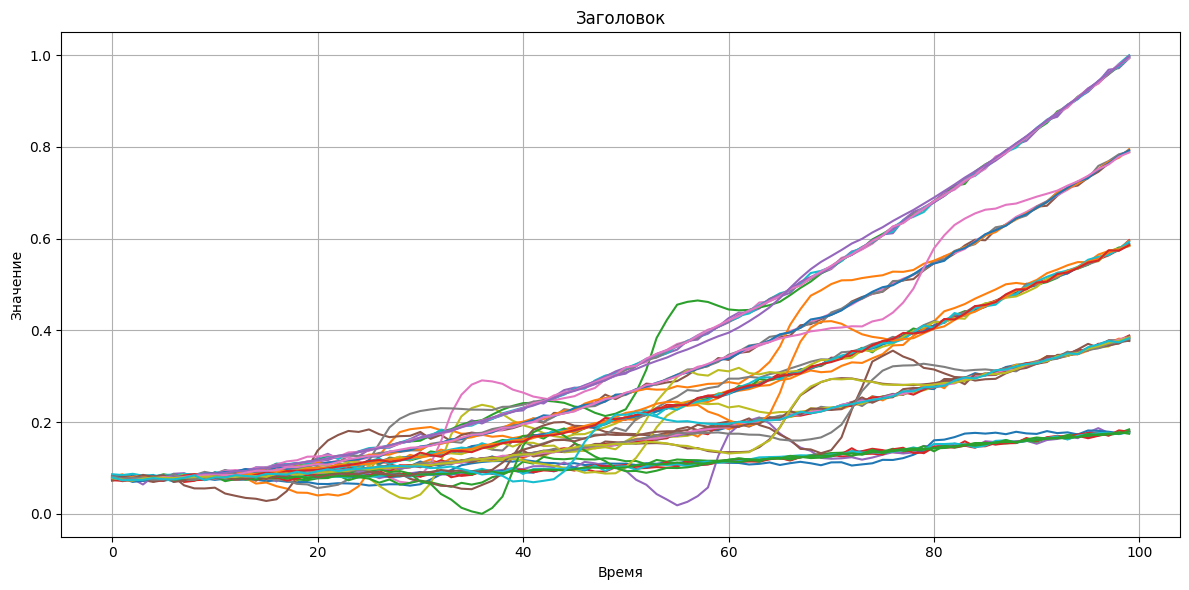

(50, 100)
0 - 0.18
1 - 0.30
2 - 0.22
3 - 0.12
4 - 0.18


In [73]:
# выбор параметров
dist_params1 = full_grid[0]
print(dist_params1)
dist_params1['n_cluster'] = 5
dist_params1['shifts'] = 1
dist_params1['noise_level'] = [0.01, 0.05]
# dist_params1['sample_size'] = 50
dist_params1['value_scale'] = [0, 1]
dist_params1['ts_length'] = 101


np.random.seed(21)
# генерация выборки
generator = quad_generator(dist_params1['n_cluster'], dist_params1['ts_length'])
harmonic_shift = harmonic_shift_generator(dist_params1['ts_length'])
sample2, labels2 = create_dist(generator, dist_params1, harmonic_shift, True, None)
sample_stats(sample2, labels2)

# обучение без применения признаков
segments_grid = range(1,6,2)

sample_name = f'{dist_params1['n_cluster']}_{dist_params1['shifts']}_{dist_params1['noise_level'][0]}_{dist_params1['value_scale'][0]}_{dist_params1['sample_size']}_{dist_params1['ts_length']}'

basic_path = 'data/Synthetic_data/mixed'

In [145]:
no_fe_extractor = Feature_extraction_method(no_fe, load_config_file('configs/manual_fe/no_fe.yaml'))

baseline_pipeline = Feature_extractor_pipeline([no_fe_extractor])
nofe_res = get_result(sample1, labels1, [1], baseline_pipeline, dist_params1, 'configs/parameters_search/trend')
nofe_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/nofe_res_{sample_name}.xlsx")

# nofe_res.loc[nofe_res.metric=='f1'].sort_values('value', ascending=False).head(15)

{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [1, 3, 5]}


Grid Search: 100%|██████████| 15/15 [00:00<00:00, 35.71it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 30], 'n_clusters': [2, 3, 4, 5, 6, 7]}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 85.92it/s]


{'n_clusters': [3, 4, 5, 6, 7], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 30.38it/s]


{'n_clusters': [3, 4, 5, 6, 7], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 122.98it/s]


In [146]:
methods = [
    Feature_extraction_method(extract_acf_statistics, load_config_file('configs/manual_fe/trend/acf_statistics.yaml'))
]

acf_pipeline = Feature_extractor_pipeline(methods)
acf_res = get_result(sample1, labels1, range(1,5), acf_pipeline, dist_params1, 'configs/parameters_search/trend')
acf_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/acf_res_{sample_name}.xlsx")

# acf_res.loc[acf_res.metric=='f1'].sort_values('value', ascending=False).head(15)

{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [1, 3, 5]}


Grid Search: 100%|██████████| 15/15 [00:00<00:00, 127.23it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 30], 'n_clusters': [2, 3, 4, 5, 6, 7]}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 110.45it/s]


{'n_clusters': [3, 4, 5, 6, 7], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 60/60 [00:00<00:00, 91.71it/s]


{'n_clusters': [3, 4, 5, 6, 7], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 30.56it/s]


{'n_clusters': [3, 4, 5, 6, 7], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 107.91it/s]


In [147]:
methods = [
    Feature_extraction_method(tsa_detrend, load_config_file('configs/manual_fe/trend/tsa_detrend.yaml'))
]

detrend_pipeline = Feature_extractor_pipeline(methods)
detrend_res = get_result(sample1, labels1, range(1,5), detrend_pipeline, dist_params1, 'configs/parameters_search/trend')
detrend_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/detrend_res_{sample_name}.xlsx")

{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [1, 3, 5]}


Grid Search:   0%|          | 0/15 [00:00<?, ?it/s]

Grid Search: 100%|██████████| 15/15 [00:00<00:00, 66.30it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 30], 'n_clusters': [2, 3, 4, 5, 6, 7]}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 96.53it/s]


...

Grid Search: 100%|██████████| 60/60 [00:00<00:00, 104.69it/s]


{'n_clusters': [3, 4, 5, 6, 7], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:02<00:00, 29.66it/s]


{'n_clusters': [3, 4, 5, 6, 7], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 109.24it/s]


In [148]:
methods = [
    Feature_extraction_method(stl_trend, load_config_file('configs/manual_fe/trend/stl_decomposition.yaml'))
]

stl_trend_pipeline = Feature_extractor_pipeline(methods)
stl_trend_res = get_result(sample1, labels1, range(1,5), stl_trend_pipeline, dist_params1,'configs/parameters_search/trend')
stl_trend_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/stl_trend_{sample_name}.xlsx")

{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [1, 3, 5]}


Grid Search: 100%|██████████| 15/15 [00:00<00:00, 77.32it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 30], 'n_clusters': [2, 3, 4, 5, 6, 7]}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 92.16it/s]


{'n_clusters': [3, 4, 5, 6, 7], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 60/60 [00:00<00:00, 92.78it/s]


{'n_clusters': [3, 4, 5, 6, 7], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 31.62it/s]


{'n_clusters': [3, 4, 5, 6, 7], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 117.79it/s]


In [149]:
methods = [
    Feature_extraction_method(paa_features, load_config_file('configs/manual_fe/trend/paa.yaml'))
]

paa_pipeline = Feature_extractor_pipeline(methods)
paa_res = get_result(sample1, labels1, range(1,5), paa_pipeline, dist_params1, 'configs/parameters_search/trend')
paa_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/paa_{sample_name}.xlsx")

e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimen

{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [1, 3, 5]}


Grid Search: 100%|██████████| 15/15 [00:00<00:00, 141.10it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 30], 'n_clusters': [2, 3, 4, 5, 6, 7]}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 123.11it/s]


...

Grid Search: 100%|██████████| 60/60 [00:00<00:00, 110.48it/s]


{'n_clusters': [3, 4, 5, 6, 7], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 32.20it/s]


{'n_clusters': [3, 4, 5, 6, 7], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 127.61it/s]


In [150]:
methods = [
    Feature_extraction_method(statistical_features, load_config_file('configs/manual_fe/trend/statistical_features.yaml'))
]

stats_pipeline = Feature_extractor_pipeline(methods)
stats_res = get_result(sample1, labels1, range(1,5), stats_pipeline, dist_params1,'configs/parameters_search/trend')
stats_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/stats_{sample_name}.xlsx")

{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [1, 3, 5]}


Grid Search: 100%|██████████| 15/15 [00:00<00:00, 107.05it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 30], 'n_clusters': [2, 3, 4, 5, 6, 7]}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 101.99it/s]


{'n_clusters': [3, 4, 5, 6, 7], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 60/60 [00:00<00:00, 83.08it/s]


{'n_clusters': [3, 4, 5, 6, 7], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:02<00:00, 25.02it/s]


{'n_clusters': [3, 4, 5, 6, 7], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 95.25it/s]


In [151]:
print(stats_res.metric.unique())
stats_res.head()

['silhouette' 'nmi' 'ari' 'accuracy' 'precision' 'recall' 'f1'
 'calinski_harabasz_score' 'davies_bouldin_score']


,parameter,model_name,metric,value,fe_method,fe_params,segment
0,"{'eps': 0.05, 'min_samples': 1, 'metric': 'euclidean'}",dbscan,silhouette,NaN,statistical_features,,1
1,"{'eps': 0.05, 'min_samples': 1, 'metric': 'euclidean'}",dbscan,nmi,0.571754,statistical_features,,1
2,"{'eps': 0.05, 'min_samples': 1, 'metric': 'euclidean'}",dbscan,ari,0.000000,statistical_features,,1
3,"{'eps': 0.05, 'min_samples': 1, 'metric': 'euclidean'}",dbscan,accuracy,0.060000,statistical_features,,1
4,"{'eps': 0.05, 'min_samples': 1, 'metric': 'euclidean'}",dbscan,precision,0.500000,statistical_features,,1


In [152]:
# stats_res.fe_method.unique()
stats_res.metric.unique()

array(['silhouette', 'nmi', 'ari', 'accuracy', 'precision', 'recall',
       'f1', 'calinski_harabasz_score', 'davies_bouldin_score'],
      dtype=object)

In [154]:
def get_top3(df, metric_name='ari'):

    return [df.loc[(df.model_name == name)&(df.metric == metric_name), ['value']].sort_values('value', ascending=False)[:3].mean().round(2).item() for name in ['dbscan', 'birch', 'sklearn_kmeans', 'agglomerative']]

def clustering_table(name, metric_name):
    return pd.DataFrame([get_top3(nofe_res, metric_name), get_top3(detrend_res, metric_name), get_top3(stl_trend_res, metric_name), get_top3(paa_res, metric_name), get_top3(stats_res, metric_name)], columns=['dbscan', 'birch', 'kmeans', 'agglomerative'], index = ['no', 'detrend', 'stl', 'paa', 'statistics']).to_excel(f'{basic_path}/{metric_name}_clustering_{name}.xlsx')

def get_top5(df):
    return [df.loc[(df.metric == metric_name), ['value']].sort_values('value', ascending=False)[:5].mean().round(2).item() for metric_name in ['ari', 'nmi', 'silhouette', 'f1']]

def evaluation_table(name):
    return pd.DataFrame([get_top5(nofe_res), get_top5(detrend_res), get_top5(stl_trend_res), get_top5(paa_res), get_top5(stats_res)], columns=['ari', 'nmi', 'silhouette', 'f1'], index =['no', 'detrend', 'stl', 'paa', 'statistics']).to_excel(f'{basic_path}/clustering_performance_{name}.xlsx')

def get_top5_segm(df, n_segm:int=1):
    return [df.loc[(df.metric == metric_name)&(df.segment ==n_segm), ['value']].sort_values('value', ascending=False)[:5].mean().round(2).item() for metric_name in ['ari', 'nmi', 'silhouette', 'f1']]

def evaluation_table_segm(name, segm):
    return pd.DataFrame([get_top5(nofe_res), get_top5_segm(detrend_res, segm), get_top5_segm(stl_trend_res, segm), get_top5_segm(paa_res, segm), get_top5_segm(stats_res, segm)], columns=['ari', 'nmi', 'silhouette', 'f1'], index =['no', 'detrend', 'stl', 'paa', 'statistics']).to_excel(f'{basic_path}/{segm}_clustering_performance_{name}.xlsx')


for metric in ['ari', 'silhouette', 'f1']:
    clustering_table(sample_name, metric)
evaluation_table(sample_name)
for i in stats_res.segment.unique():
    evaluation_table_segm(sample_name, i)

In [75]:
labels1, labels2

(array([0, 2, 2, 0, 4, 3, 3, 3, 2, 4, 1, 1, 4, 2, 0, 1, 4, 4, 1, 4, 0, 2,
        0, 0, 4, 1, 4, 1, 1, 0, 2, 3, 0, 1, 1, 1, 1, 2, 2, 2, 3, 2, 0, 2,
        4, 1, 3, 1, 1, 1], dtype=int64),
 array([0, 2, 2, 0, 4, 3, 3, 3, 2, 4, 1, 1, 4, 2, 0, 1, 4, 4, 1, 4, 0, 2,
        0, 0, 4, 1, 4, 1, 1, 0, 2, 3, 0, 1, 1, 1, 1, 2, 2, 2, 3, 2, 0, 2,
        4, 1, 3, 1, 1, 1], dtype=int64))

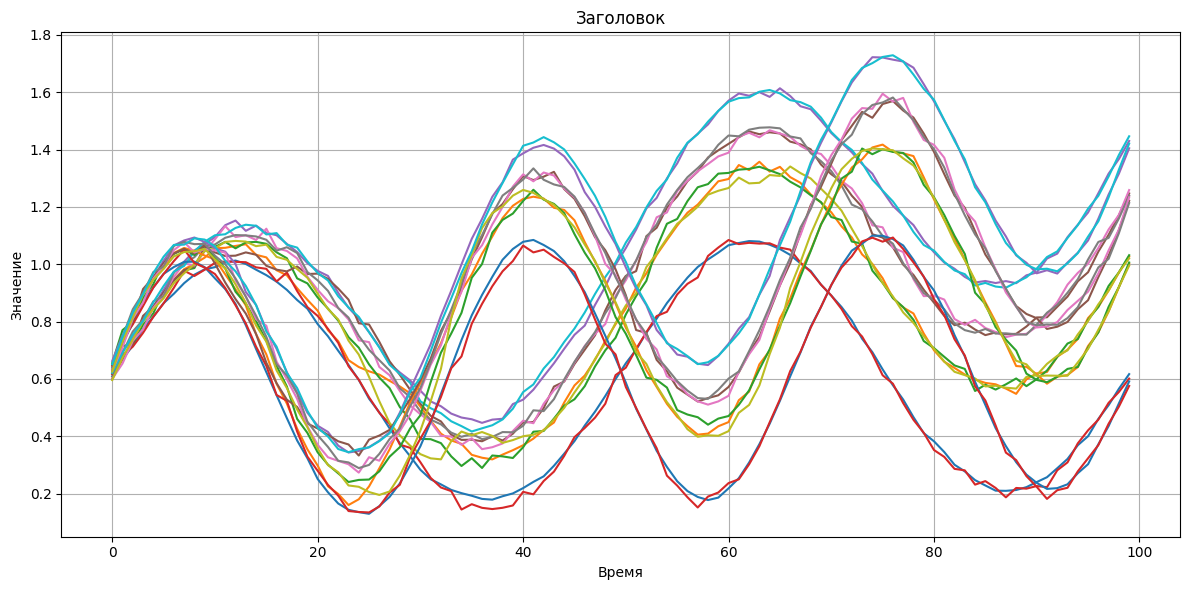

In [115]:
sample_cls1 = sample_seasonal + sample1
labels_cls1 = [0] * sample_cls1.shape[0]

# sample_cls2 = sample2[np.where(pd.Series(labels2).isin([3,4]))] +sample_seasonal[np.where(pd.Series(labels2).isin([3,4]))]
sample_cls2 = sample_seasonal2 + sample1
labels_cls2 = [1] * sample_cls2.shape[0]
 
final_sample1 = np.concatenate([sample_cls1, sample_cls2])

plot_series([row for row in sample_cls1[:10]] + [row for row in sample_cls2[:10]], show_legend=False)

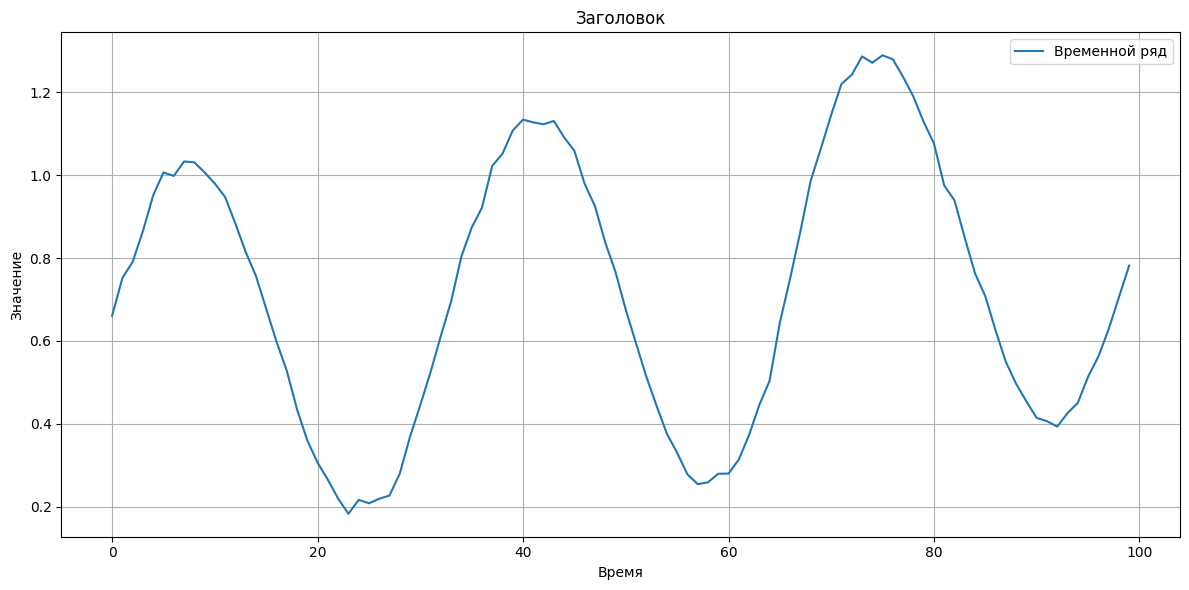

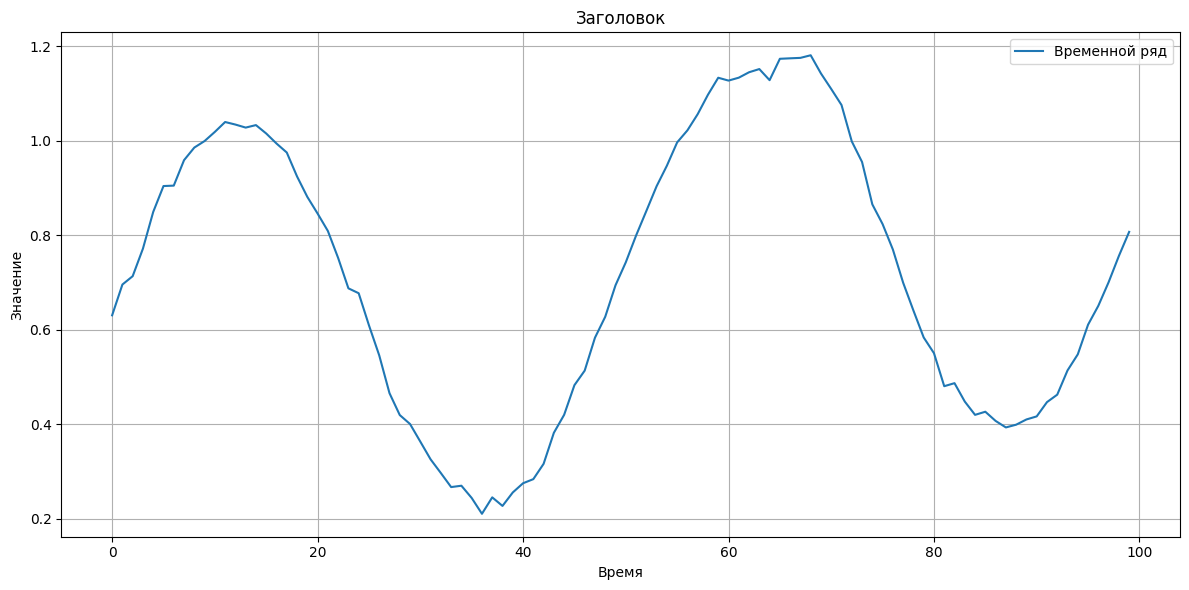

In [116]:
plot_series(sample_cls2[-2])
plot_series(sample_cls1[-2])

In [117]:
sample_cls1.shape

(50, 100)

In [118]:
full_sample = np.concatenate([sample_cls1,sample_cls2])
full_labels = labels_cls1 + labels_cls2

print(len(full_labels), len(full_sample))
basic_path = 'data/Synthetic_data/mixed'

100 100


In [119]:
no_fe_extractor = Feature_extraction_method(no_fe, load_config_file('configs/manual_fe/no_fe.yaml'))

baseline_pipeline = Feature_extractor_pipeline([no_fe_extractor])
nofe_res = get_result(full_sample, full_labels, [1], baseline_pipeline, dist_params1, 'configs/parameters_search/trend')
nofe_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/nofe_res_{sample_name}.xlsx")

# nofe_res.loc[nofe_res.metric=='f1'].sort_values('value', ascending=False).head(15)

{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [1, 3, 5]}


Grid Search: 100%|██████████| 15/15 [00:00<00:00, 64.50it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 30], 'n_clusters': [2, 3]}


Grid Search: 100%|██████████| 20/20 [00:00<00:00, 71.40it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 30.66it/s]


{'n_clusters': [2, 3], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 105.25it/s]


In [120]:
methods = [
    Feature_extraction_method(extract_acf_statistics, load_config_file('configs/manual_fe/trend/acf_statistics.yaml'))
]

acf_pipeline = Feature_extractor_pipeline(methods)
acf_res = get_result(full_sample, full_labels, range(1,5), acf_pipeline, dist_params1, 'configs/parameters_search/trend')
acf_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/acf_res_{sample_name}.xlsx")

# acf_res.loc[acf_res.metric=='f1'].sort_values('value', ascending=False).head(15)

{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [1, 3, 5]}


Grid Search: 100%|██████████| 15/15 [00:00<00:00, 100.38it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 30], 'n_clusters': [2, 3]}


Grid Search: 100%|██████████| 20/20 [00:00<00:00, 81.04it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 20/20 [00:00<00:00, 86.58it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 33.19it/s]


{'n_clusters': [2, 3], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 103.99it/s]


In [121]:
methods = [
    Feature_extraction_method(tsa_detrend, load_config_file('configs/manual_fe/trend/tsa_detrend.yaml'))
]

detrend_pipeline = Feature_extractor_pipeline(methods)
detrend_res = get_result(sample1, labels1, range(1,5), detrend_pipeline, dist_params1, 'configs/parameters_search/trend')
detrend_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/detrend_res_{sample_name}.xlsx")

{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [1, 3, 5]}


Grid Search: 100%|██████████| 15/15 [00:00<00:00, 71.69it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 30], 'n_clusters': [2, 3]}


Grid Search: 100%|██████████| 20/20 [00:00<00:00, 88.48it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 20/20 [00:00<00:00, 112.36it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 33.91it/s]


{'n_clusters': [2, 3], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 126.24it/s]


In [122]:
methods = [
    Feature_extraction_method(stl_trend, load_config_file('configs/manual_fe/trend/stl_decomposition.yaml'))
]

stl_trend_pipeline = Feature_extractor_pipeline(methods)
stl_trend_res = get_result(full_sample, full_labels, range(1,5), stl_trend_pipeline, dist_params1,'configs/parameters_search/trend')
stl_trend_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/stl_trend_{sample_name}.xlsx")

{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [1, 3, 5]}


Grid Search: 100%|██████████| 15/15 [00:00<00:00, 71.10it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 30], 'n_clusters': [2, 3]}


Grid Search: 100%|██████████| 20/20 [00:00<00:00, 73.26it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 20/20 [00:00<00:00, 82.95it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 33.51it/s]


{'n_clusters': [2, 3], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 105.75it/s]


In [123]:
methods = [
    Feature_extraction_method(paa_features, load_config_file('configs/manual_fe/trend/paa.yaml'))
]

paa_pipeline = Feature_extractor_pipeline(methods)
paa_res = get_result(full_sample, full_labels, range(1,5), paa_pipeline, dist_params1, 'configs/parameters_search/trend')
paa_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/paa_{sample_name}.xlsx")

e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimen

{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [1, 3, 5]}


Grid Search: 100%|██████████| 15/15 [00:00<00:00, 145.47it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 30], 'n_clusters': [2, 3]}


Grid Search: 100%|██████████| 20/20 [00:00<00:00, 109.23it/s]


...

Grid Search: 100%|██████████| 20/20 [00:00<00:00, 70.94it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 33.33it/s]


{'n_clusters': [2, 3], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 93.75it/s]


In [124]:
methods = [
    Feature_extraction_method(statistical_features, load_config_file('configs/manual_fe/trend/statistical_features.yaml'))
]

stats_pipeline = Feature_extractor_pipeline(methods)
stats_res = get_result(full_sample, full_labels, range(1,5), stats_pipeline, dist_params1,'configs/parameters_search/trend')
stats_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/stats_{sample_name}.xlsx")

{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [1, 3, 5]}


Grid Search: 100%|██████████| 15/15 [00:00<00:00, 140.43it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 30], 'n_clusters': [2, 3]}


Grid Search: 100%|██████████| 20/20 [00:00<00:00, 94.78it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 20/20 [00:00<00:00, 82.64it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 31.41it/s]


{'n_clusters': [2, 3], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 106.14it/s]


In [125]:
def get_top3(df, metric_name='ari'):

    return [df.loc[(df.model_name == name)&(df.metric == metric_name), ['value']].sort_values('value', ascending=False)[:3].mean().round(2).item() for name in ['dbscan', 'birch', 'sklearn_kmeans', 'agglomerative']]

def clustering_table(name, metric_name):
    return pd.DataFrame([get_top3(nofe_res, metric_name), get_top3(detrend_res, metric_name), get_top3(stl_trend_res, metric_name), get_top3(paa_res, metric_name), get_top3(stats_res, metric_name)], columns=['dbscan', 'birch', 'kmeans', 'agglomerative'], index = ['no', 'detrend', 'stl', 'paa', 'statistics']).to_excel(f'{basic_path}/{metric_name}_clustering_{name}.xlsx')

def get_top5(df):
    return [df.loc[(df.metric == metric_name), ['value']].sort_values('value', ascending=False)[:5].mean().round(2).item() for metric_name in ['ari', 'nmi', 'silhouette', 'f1']]

def evaluation_table(name):
    return pd.DataFrame([get_top5(nofe_res), get_top5(detrend_res), get_top5(stl_trend_res), get_top5(paa_res), get_top5(stats_res)], columns=['ari', 'nmi', 'silhouette', 'f1'], index =['no', 'detrend', 'stl', 'paa', 'statistics']).to_excel(f'{basic_path}/clustering_performance_{name}.xlsx')

def get_top5_segm(df, n_segm:int=1):
    return [df.loc[(df.metric == metric_name)&(df.segment ==n_segm), ['value']].sort_values('value', ascending=False)[:5].mean().round(2).item() for metric_name in ['ari', 'nmi', 'silhouette', 'f1']]

def evaluation_table_segm(name, segm):
    return pd.DataFrame([get_top5(nofe_res), get_top5_segm(detrend_res, segm), get_top5_segm(stl_trend_res, segm), get_top5_segm(paa_res, segm), get_top5_segm(stats_res, segm)], columns=['ari', 'nmi', 'silhouette', 'f1'], index =['no', 'detrend', 'stl', 'paa', 'statistics']).to_excel(f'{basic_path}/{segm}_clustering_performance_{name}.xlsx')


for metric in ['ari', 'silhouette', 'f1']:
    clustering_table(sample_name, metric)
evaluation_table(sample_name)
for i in stats_res.segment.unique():
    evaluation_table_segm(sample_name, i)

In [25]:
# базовые одиночные методы выделения признаков

# acf analys

# tsa_detrend_extractor = Feature_extraction_method(tsa_detrend, load_config_file('configs/manual_fe/tsa_detrend.yaml'))
# stats_extractor = Feature_extraction_method(statistical_features, load_config_file('configs/manual_fe/statistical_features.yaml'))
# paa_extractor = Feature_extraction_method(paa_features, load_config_file('configs/manual_fe/paa.yaml'))
# stl_trend_extractor = Feature_extraction_method(stl_trend, load_config_file('configs/manual_fe/stl_decomposition.yaml'))


In [47]:
fe1 = Feature_extraction_method(tsa_detrend, load_config_file('configs/manual_fe/trend/tsa_detrend.yaml'))

# plot_series( + [fe1.infer(row, {'order':1}) for row in full_sample[full_labels==1]], show_legend=False)

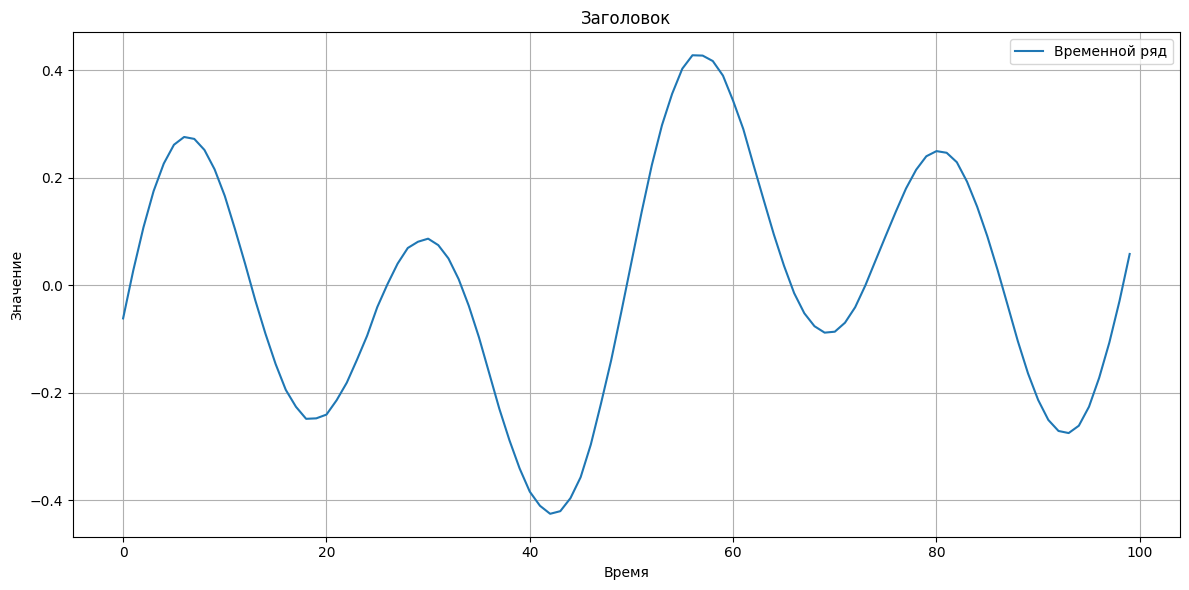

In [53]:
plot_series(np.mean([fe1.infer(row, {'order':1}) for row in full_sample[np.array(full_labels)==0]], axis=0))

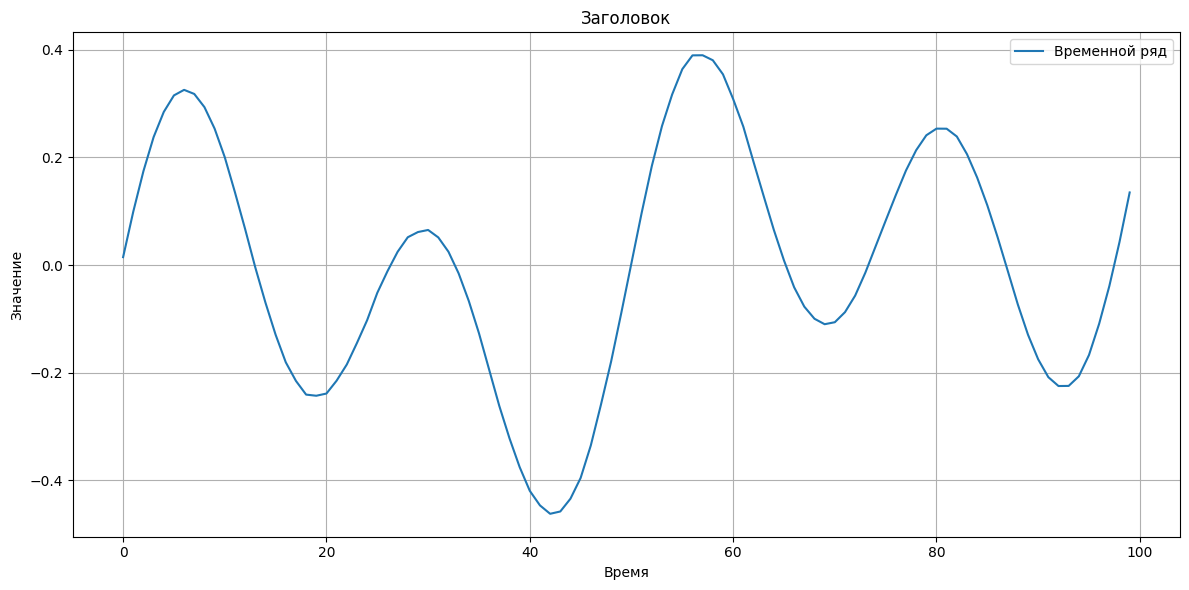

In [54]:
plot_series(np.mean([fe1.infer(row, {'order':1}) for row in full_sample[np.array(full_labels)==1]], axis=0))

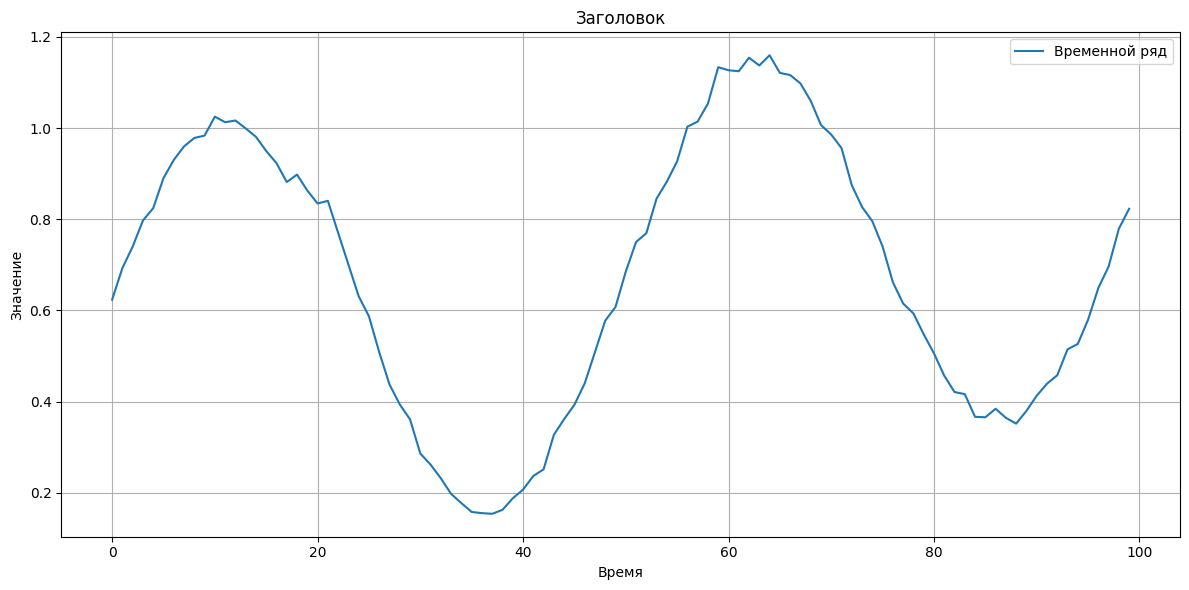

In [64]:
plot_series(full_sample[83])

In [65]:
full_labels

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1]

In [31]:
full_sample[np.array(full_labels)==0].shape, full_sample[np.array(full_labels)==1].shape

((50, 100), (50, 100))

array([[0.60226743, 0.67548037, 0.70990143, ..., 0.51247577, 0.55336211,
        0.60970734],
       [0.60426565, 0.66915857, 0.72768323, ..., 0.90926531, 0.9633874 ,
        1.01186887],
       [0.62598761, 0.69525626, 0.70925053, ..., 0.91606272, 0.97886106,
        1.01174008],
       ...,
       [0.62439491, 0.67173709, 0.72938851, ..., 0.71067673, 0.74932303,
        0.79913947],
       [0.68276491, 0.7898335 , 0.87626517, ..., 0.55974187, 0.64630107,
        0.76475452],
       [0.66340034, 0.77480786, 0.88682294, ..., 0.57380204, 0.65031197,
        0.75498527]])

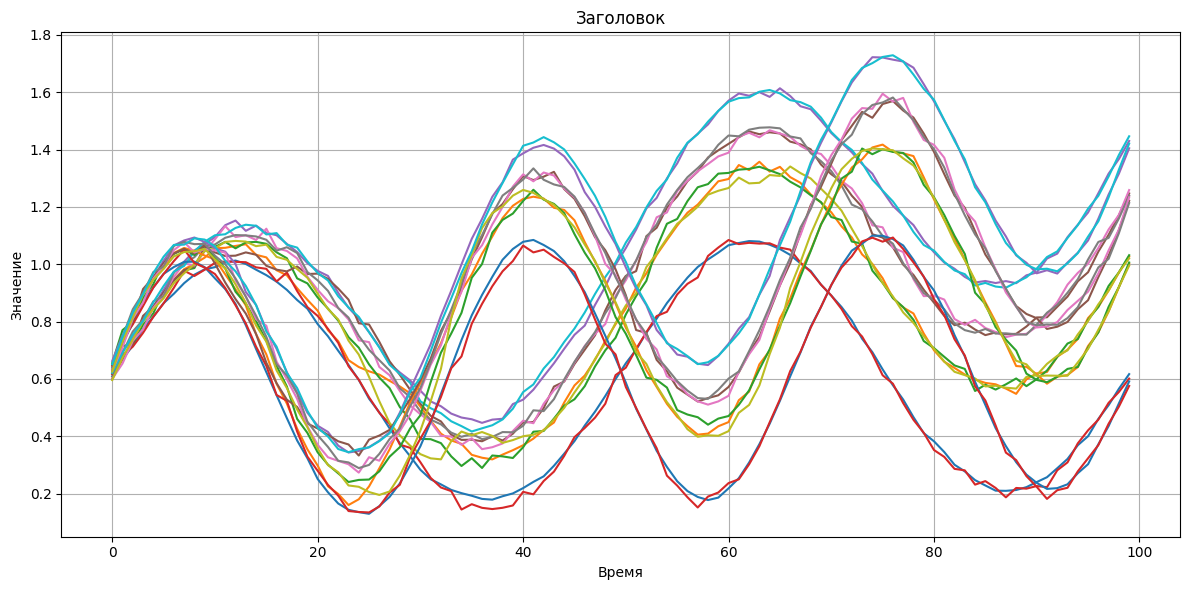

In [126]:
sample_cls1 = sample_seasonal + sample1
labels_cls1 = [0] * sample_cls1.shape[0]

# sample_cls2 = sample2[np.where(pd.Series(labels2).isin([3,4]))] +sample_seasonal[np.where(pd.Series(labels2).isin([3,4]))]
sample_cls2 = sample_seasonal2 + sample1
labels_cls2 = [1] * sample_cls2.shape[0]
 
final_sample1 = np.concatenate([sample_cls1, sample_cls2])

plot_series([row for row in sample_cls1[:10]] + [row for row in sample_cls2[:10]], show_legend=False)

In [132]:
full_sample = np.concatenate([sample_cls1,sample_cls2])
full_labels = labels_cls1 + labels_cls2

print(len(full_labels), len(full_sample))
basic_path = 'data/Synthetic_data/mixed1'

100 100


In [133]:
no_fe_extractor = Feature_extraction_method(no_fe, load_config_file('configs/manual_fe/no_fe.yaml'))

baseline_pipeline = Feature_extractor_pipeline([no_fe_extractor])
nofe_res = get_result(full_sample, full_labels, [1], baseline_pipeline, dist_params1, 'configs/parameters_search/trend')
nofe_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/nofe_res_{sample_name}.xlsx")

# nofe_res.loc[nofe_res.metric=='f1'].sort_values('value', ascending=False).head(15)

{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [1, 3, 5]}


Grid Search: 100%|██████████| 15/15 [00:00<00:00, 64.90it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 30], 'n_clusters': [2, 3]}


Grid Search: 100%|██████████| 20/20 [00:00<00:00, 80.78it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 32.96it/s]


{'n_clusters': [2, 3], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 105.33it/s]


In [134]:
methods = [
    Feature_extraction_method(dft_approximation, load_config_file('configs/manual_fe/dft_approximation.yaml'))
]

dft_apr_pipeline = Feature_extractor_pipeline(methods)
dft_apr_res = get_result(full_sample, full_labels, range(1,2), dft_apr_pipeline, dist_params1, 'configs/parameters_search/')
dft_apr_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/dft_apr_res_{sample_name}.xlsx")

{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 64.70it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3]}


Grid Search: 100%|██████████| 100/100 [00:01<00:00, 81.03it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 100/100 [00:01<00:00, 68.98it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 36.48it/s]


{'n_clusters': [2, 3], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 96.85it/s]


In [135]:
methods = [
    Feature_extraction_method(dft_components, load_config_file('configs/manual_fe/dft_components.yaml'))
]

dft_comp_pipeline = Feature_extractor_pipeline(methods)
dft_comp_res = get_result(full_sample, full_labels, range(1,2), dft_comp_pipeline, dist_params1, 'configs/parameters_search/')
dft_comp_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/dft_comp_res_{sample_name}.xlsx")

{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 123.45it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3]}


Grid Search: 100%|██████████| 100/100 [00:01<00:00, 87.23it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 100/100 [00:01<00:00, 76.44it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 41.52it/s]


{'n_clusters': [2, 3], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 111.01it/s]


In [136]:
methods = [
    Feature_extraction_method(dft_signal, load_config_file('configs/manual_fe/dft_signal.yaml'))
]

dft_sig_pipeline = Feature_extractor_pipeline(methods)
dft_sig_res = get_result(full_sample, full_labels, range(1,2), dft_sig_pipeline, dist_params1, 'configs/parameters_search/')
dft_sig_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/dft_sig_res_{sample_name}.xlsx")

{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 61.39it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3]}


Grid Search: 100%|██████████| 100/100 [00:01<00:00, 85.70it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 100/100 [00:01<00:00, 80.53it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 42.64it/s]


{'n_clusters': [2, 3], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 104.35it/s]


In [137]:
methods = [
    Feature_extraction_method(extract_acf_statistics, load_config_file('configs/manual_fe/trend/acf_statistics.yaml'))
]

acf_pipeline = Feature_extractor_pipeline(methods)
acf_res = get_result(full_sample, full_labels, range(1,2), acf_pipeline, dist_params1, 'configs/parameters_search/trend')
acf_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/acf_res_{sample_name}.xlsx")

# acf_res.loc[acf_res.metric=='f1'].sort_values('value', ascending=False).head(15)

{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [1, 3, 5]}


Grid Search: 100%|██████████| 15/15 [00:00<00:00, 129.81it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 30], 'n_clusters': [2, 3]}


Grid Search: 100%|██████████| 20/20 [00:00<00:00, 88.50it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 20/20 [00:00<00:00, 86.55it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 32.17it/s]


{'n_clusters': [2, 3], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 112.13it/s]


In [138]:
methods = [
    Feature_extraction_method(dwt_features, load_config_file('configs/manual_fe/dwt_features.yaml'))
]

dwt_feat_pipeline = Feature_extractor_pipeline(methods)
dwt_feat_res = get_result(full_sample, full_labels, range(1,2), dwt_feat_pipeline, dist_params1, 'configs/parameters_search')
dwt_feat_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/dwt_feat_res_{sample_name}.xlsx")

# acf_res.loc[acf_res.metric=='f1'].sort_values('value', ascending=False).head(15)

{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 109.85it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3]}


Grid Search: 100%|██████████| 100/100 [00:01<00:00, 92.08it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 100/100 [00:01<00:00, 82.28it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 38.18it/s]


{'n_clusters': [2, 3], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 114.78it/s]


In [139]:
methods = [
    Feature_extraction_method(dwt_signal, load_config_file('configs/manual_fe/dwt_signal.yaml'))
]

dwt_sig_pipeline = Feature_extractor_pipeline(methods)
dwt_sig_res = get_result(full_sample, full_labels, range(1,2), dwt_sig_pipeline, dist_params1, 'configs/parameters_search')
dwt_sig_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/dwt_sig_res_{sample_name}.xlsx")

# acf_res.loc[acf_res.metric=='f1'].sort_values('value', ascending=False).head(15)

{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 64.93it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3]}


Grid Search: 100%|██████████| 100/100 [00:01<00:00, 81.54it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 100/100 [00:01<00:00, 78.74it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 38.77it/s]


{'n_clusters': [2, 3], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 96.33it/s]


In [140]:
methods = [
    Feature_extraction_method(signal_peaks_features, load_config_file('configs/manual_fe/signal_peaks.yaml'))
]

sig_peaks_pipeline = Feature_extractor_pipeline(methods)
sig_peaks_res = get_result(full_sample, full_labels, range(1,2), sig_peaks_pipeline, dist_params1, 'configs/parameters_search')
sig_peaks_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/sig_peaks_res_{sample_name}.xlsx")


{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 80.64it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3]}


Grid Search: 100%|██████████| 100/100 [00:01<00:00, 69.50it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 38.80it/s]


{'n_clusters': [2, 3], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 102.49it/s]


In [141]:
methods = [
    Feature_extraction_method(stl_seasonal, load_config_file('configs/manual_fe/stl_decomposition.yaml'))
]

stl_seas_pipeline = Feature_extractor_pipeline(methods)
stl_seas_res = get_result(full_sample, full_labels, range(1,5), stl_seas_pipeline, dist_params1, 'configs/parameters_search')
stl_seas_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/stl_seas_res_{sample_name}.xlsx")


{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 64.53it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3]}


Grid Search: 100%|██████████| 100/100 [00:00<00:00, 108.91it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 100/100 [00:01<00:00, 61.40it/s]


{'n_clusters': [2, 3], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 39.14it/s]


{'n_clusters': [2, 3], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 24/24 [00:00<00:00, 99.35it/s] 


In [142]:
def get_top3(df, metric_name='ari'):

    return [df.loc[(df.model_name == name)&(df.metric == metric_name), ['value']].sort_values('value', ascending=False)[:3].mean().round(2).item() for name in ['dbscan', 'birch', 'sklearn_kmeans', 'agglomerative']]


def clustering_table(name, metric_name):
    return pd.DataFrame([get_top3(nofe_res, metric_name), get_top3(dft_apr_res, metric_name), get_top3(dft_comp_res, metric_name), get_top3(dft_sig_res, metric_name), get_top3(acf_res, metric_name), get_top3(dwt_feat_res, metric_name), get_top3(dwt_sig_res, metric_name), get_top3(sig_peaks_res, metric_name), get_top3(stl_seas_res, metric_name)], columns=['dbscan', 'birch', 'kmeans', 'agglomerative'], index = ['no', 'dft_approximation', 'dft_components', 'dft_signal', 'acf_features', 'dwt_features', 'dwt_signal', 'signal_peaks_features', 'stl_seasonal']).to_excel(f'{basic_path}/{metric_name}_clustering_{name}.xlsx')

def get_top5(df):
    return [df.loc[(df.metric == metric_name), ['value']].sort_values('value', ascending=False)[:5].mean().round(2).item() for metric_name in ['ari', 'nmi', 'silhouette', 'f1']]

def evaluation_table(name):
    return pd.DataFrame([get_top5(nofe_res), get_top5(dft_apr_res), get_top5(dft_comp_res), get_top5(dft_sig_res), get_top5(acf_res), get_top5(dwt_feat_res), get_top5(dwt_sig_res), get_top5(sig_peaks_res), get_top5(stl_seas_res)], columns=['ari', 'nmi', 'silhouette', 'f1'], index =['no', 'dft_approximation', 'dft_components', 'dft_signal', 'acf_features', 'dwt_features', 'dwt_signal', 'signal_peaks_features', 'stl_seasonal']).to_excel(f'{basic_path}/clustering_performance_{name}.xlsx')

def get_top5_segm(df, n_segm:int=1):
    return [df.loc[(df.metric == metric_name)&(df.segment ==n_segm), ['value']].sort_values('value', ascending=False)[:5].mean().round(2).item() for metric_name in ['ari', 'nmi', 'silhouette', 'f1']]

def evaluation_table_segm(name, segm):
    return pd.DataFrame([get_top5(nofe_res), get_top5_segm(dft_apr_res, segm), get_top5_segm(dft_comp_res, segm), get_top5_segm(dft_sig_res, segm), get_top5_segm(acf_res, segm), get_top5_segm(dwt_feat_res, segm), get_top5_segm(dwt_sig_res, segm), get_top5_segm(sig_peaks_res, segm), get_top5_segm(stl_seas_res, segm)], columns=['ari', 'nmi', 'silhouette', 'f1'], index =['no', 'dft_approximation', 'dft_components', 'dft_signal', 'acf_features', 'dwt_features', 'dwt_signal', 'signal_peaks_features', 'stl_seasonal']).to_excel(f'{basic_path}/{segm}_clustering_performance_{name}.xlsx')


for metric in ['ari', 'silhouette', 'f1']:
    clustering_table(sample_name, metric)
evaluation_table(sample_name)
for i in sig_peaks_res.segment.unique():
    evaluation_table_segm(sample_name, i)

In [25]:
# Инициализируем модель
model = DBSCAN_model()
# model = Sklearn_kmeans_model()

# Scorer
scorer = Clustering_scorer(
    metrics=None,
    debug=True  # Включаем дебаг-режим
)
params_grid1 = adapt_dbscan(load_config_file('configs/parameters_search/dbscan.yaml'), dist_params1) 
# params_grid1 = load_config_file('configs/parameters_search/dbscan.yaml')
# params_grid1 = load_config_file('configs/parameters_search/sklearn_kmeans.yaml')

n_segment = 1
final_df = pd.DataFrame()

for n_segment in range(1, 5):
    features = pipeline1.batch_extract(sample1, True, n_segments=n_segment)

    for (X_train, fe_params) in features:
        print(X_train.shape, fe_params)

        # Запуск поиска
        df_results = scorer.grid_search(model=model, X=X_train, y_true=labels1, model_name="kmeans", param_grid=params_grid1)
        df_results['fe_method']= list(fe_params.keys())[0]
        df_results['fe_params']= '__'.join(['_'.join([str(k), str(v)]) for k,v in list(fe_params.values())[0].items()])
        df_results['segment'] = n_segment 
        
        final_df = pd.concat([final_df, df_results])


# Запуск поиска
df_results = scorer.grid_search(model=model, X=sample1, y_true=labels1, model_name="kmeans", param_grid=params_grid1)

# Вывод результатов
print(df_results.head())

# # Получение данных для дебага
# debug_data = scorer.get_debug_data()

# # Просмотр первого результата
# first_run = debug_data[0]
# print("Параметры:", first_run["params"])
# print("Метки кластеров:", first_run["pred_labels"])
# print("Истинные метки:", first_run["true_labels"])
# print("Метрики:", first_run["metrics"])

(50, 5) {'extract_acf_statistics': {'n_lags': 5}}
{'eps': [0.05, 1.0375, 2.025, 3.0125, 4.0], 'min_samples': [1, 6]}


Grid Search:   0%|          | 0/10 [00:00<?, ?it/s]

Grid Search: 100%|██████████| 10/10 [00:00<00:00, 91.60it/s]


(50, 5) {'extract_acf_statistics': {'n_lags': 10}}
{'eps': [0.05, 1.0375, 2.025, 3.0125, 4.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 86.96it/s]


...

(50, 20) {'extract_acf_statistics': {'n_lags': 30}}
{'eps': [0.05, 1.0375, 2.025, 3.0125, 4.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 106.19it/s]


{'eps': [0.05, 1.0375, 2.025, 3.0125, 4.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 77.18it/s]

                                                parameter model_name  \
0  {'eps': 0.05, 'min_samples': 1, 'metric': 'euclidean'}     kmeans   
1  {'eps': 0.05, 'min_samples': 1, 'metric': 'euclidean'}     kmeans   
2  {'eps': 0.05, 'min_samples': 1, 'metric': 'euclidean'}     kmeans   
3  {'eps': 0.05, 'min_samples': 1, 'metric': 'euclidean'}     kmeans   
4  {'eps': 0.05, 'min_samples': 1, 'metric': 'euclidean'}     kmeans   

       metric     value  
0  silhouette       NaN  
1         nmi  0.571754  
2         ari  0.000000  
3    accuracy  0.060000  
4   precision  0.500000  


In [26]:
print(final_df.shape)
final_df[final_df.metric=='f1'].sort_values('value', ascending=False).head(15)

(2160, 7)


,parameter,model_name,metric,value,fe_method,fe_params,segment
6,"{'eps': 0.05, 'min_samples': 1, 'metric': 'euclidean'}",kmeans,f1,0.241339,extract_acf_statistics,n_lags_5,1
60,"{'eps': 3.0125, 'min_samples': 1, 'metric': 'euclidean'}",kmeans,f1,0.220833,extract_acf_statistics,n_lags_5,4
6,"{'eps': 0.05, 'min_samples': 1, 'metric': 'euclidean'}",kmeans,f1,0.205848,extract_acf_statistics,n_lags_25,1
6,"{'eps': 0.05, 'min_samples': 1, 'metric': 'euclidean'}",kmeans,f1,0.205848,extract_acf_statistics,n_lags_30,1
15,"{'eps': 0.05, 'min_samples': 6, 'metric': 'euclidean'}",kmeans,f1,0.201086,extract_acf_statistics,n_lags_10,1
24,"{'eps': 1.0375, 'min_samples': 1, 'metric': 'euclidean'}",kmeans,f1,0.199066,extract_acf_statistics,n_lags_25,3
6,"{'eps': 0.05, 'min_samples': 1, 'metric': 'euclidean'}",kmeans,f1,0.198901,extract_acf_statistics,n_lags_15,1
42,"{'eps': 2.025, 'min_samples': 1, 'metric': 'euclidean'}",kmeans,f1,0.192063,extract_acf_statistics,n_lags_10,4
6,"{'eps': 0.05, 'min_samples': 1, 'metric': 'euclidean'}",kmeans,f1,0.189666,extract_acf_statistics,n_lags_10,1
24,"{'eps': 1.0375, 'min_samples': 1, 'metric': 'euclidean'}",kmeans,f1,0.188730,extract_acf_statistics,n_lags_20,4


In [27]:
df_results[df_results.metric=='f1'].sort_values('value', ascending=False).head(15)
# df_results.parameter.drop_duplicates()

,parameter,model_name,metric,value
87,"{'eps': 4.0, 'min_samples': 6, 'metric': 'euclidean'}",kmeans,f1,0.666667
78,"{'eps': 4.0, 'min_samples': 1, 'metric': 'euclidean'}",kmeans,f1,0.651515
69,"{'eps': 3.0125, 'min_samples': 6, 'metric': 'euclidean'}",kmeans,f1,0.629167
51,"{'eps': 2.025, 'min_samples': 6, 'metric': 'euclidean'}",kmeans,f1,0.556944
60,"{'eps': 3.0125, 'min_samples': 1, 'metric': 'euclidean'}",kmeans,f1,0.510119
42,"{'eps': 2.025, 'min_samples': 1, 'metric': 'euclidean'}",kmeans,f1,0.467137
24,"{'eps': 1.0375, 'min_samples': 1, 'metric': 'euclidean'}",kmeans,f1,0.144444
6,"{'eps': 0.05, 'min_samples': 1, 'metric': 'euclidean'}",kmeans,f1,0.094444
15,"{'eps': 0.05, 'min_samples': 6, 'metric': 'euclidean'}",kmeans,f1,0.000000
33,"{'eps': 1.0375, 'min_samples': 6, 'metric': 'euclidean'}",kmeans,f1,0.000000


In [ ]:
no_fe_extractor = Feature_extraction_method(no_fe, load_config_file('configs/manual_fe/no_fe.yaml'))

baseline_pipeline = Feature_extractor_pipeline([no_fe_extractor])
nofe_res = get_result(full_sample, labels_seasonal, [1], baseline_pipeline, dist_params1, 'configs/parameters_search/trend')
nofe_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/nofe_res_{sample_name}.xlsx")

# nofe_res.loc[nofe_res.metric=='f1'].sort_values('value', ascending=False).head(15)

{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [1, 3, 5]}


Grid Search:   0%|          | 0/15 [00:00<?, ?it/s]

Grid Search: 100%|██████████| 15/15 [00:00<00:00, 32.64it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 30], 'n_clusters': [2, 3, 4]}


Grid Search: 100%|██████████| 30/30 [00:00<00:00, 76.74it/s]


{'n_clusters': [2, 3, 4], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


Grid Search:  69%|██████▉   | 25/36 [00:01<00:00, 16.30it/s]


KeyboardInterrupt: 

In [ ]:
methods = [
    Feature_extraction_method(dft_approximation, load_config_file('configs/manual_fe/dft_approximation.yaml'))
]

dft_apr_pipeline = Feature_extractor_pipeline(methods)
dft_apr_res = get_result(sample_seasonal, labels_seasonal, range(1,2), dft_apr_pipeline, dist_params1, 'configs/parameters_search/')
dft_apr_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/dft_apr_res_{sample_name}.xlsx")

{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 68.01it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


Grid Search: 100%|██████████| 550/550 [00:06<00:00, 86.29it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 550/550 [00:06<00:00, 87.54it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 33.40it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 116.04it/s]


In [ ]:
methods = [
    Feature_extraction_method(dft_components, load_config_file('configs/manual_fe/dft_components.yaml'))
]

dft_comp_pipeline = Feature_extractor_pipeline(methods)
dft_comp_res = get_result(sample_seasonal, labels_seasonal, range(1,2), dft_comp_pipeline, dist_params1, 'configs/parameters_search/')
dft_comp_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/dft_comp_res_{sample_name}.xlsx")

{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 139.03it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


Grid Search: 100%|██████████| 550/550 [00:05<00:00, 95.36it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 550/550 [00:06<00:00, 85.45it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 34.07it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 112.11it/s]


In [ ]:
methods = [
    Feature_extraction_method(dft_signal, load_config_file('configs/manual_fe/dft_signal.yaml'))
]

dft_sig_pipeline = Feature_extractor_pipeline(methods)
dft_sig_res = get_result(sample_seasonal, labels_seasonal, range(1,2), dft_sig_pipeline, dist_params1, 'configs/parameters_search/')
dft_sig_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/dft_sig_res_{sample_name}.xlsx")

{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 62.88it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


Grid Search: 100%|██████████| 550/550 [00:06<00:00, 90.19it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 550/550 [00:06<00:00, 91.22it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 34.53it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 114.25it/s]


In [ ]:
methods = [
    Feature_extraction_method(extract_acf_statistics, load_config_file('configs/manual_fe/trend/acf_statistics.yaml'))
]

acf_pipeline = Feature_extractor_pipeline(methods)
acf_res = get_result(sample_seasonal, labels_seasonal, range(1,2), acf_pipeline, dist_params1, 'configs/parameters_search/trend')
acf_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/acf_res_{sample_name}.xlsx")

# acf_res.loc[acf_res.metric=='f1'].sort_values('value', ascending=False).head(15)

{'eps': [0.05, 1.2875, 2.525, 3.7625, 5.0], 'min_samples': [1, 3, 5]}


Grid Search: 100%|██████████| 15/15 [00:00<00:00, 148.97it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 30], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


Grid Search: 100%|██████████| 110/110 [00:00<00:00, 127.80it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 110/110 [00:01<00:00, 90.81it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:02<00:00, 25.49it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 103.95it/s]


In [ ]:
methods = [
    Feature_extraction_method(dwt_features, load_config_file('configs/manual_fe/dwt_features.yaml'))
]

dwt_feat_pipeline = Feature_extractor_pipeline(methods)
dwt_feat_res = get_result(sample_seasonal, labels_seasonal, range(1,2), dwt_feat_pipeline, dist_params1, 'configs/parameters_search')
dwt_feat_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/dwt_feat_res_{sample_name}.xlsx")

# acf_res.loc[acf_res.metric=='f1'].sort_values('value', ascending=False).head(15)

{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 152.07it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


Grid Search: 100%|██████████| 550/550 [00:04<00:00, 134.98it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 550/550 [00:05<00:00, 106.36it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 34.95it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 114.63it/s]


In [ ]:
methods = [
    Feature_extraction_method(dwt_signal, load_config_file('configs/manual_fe/dwt_signal.yaml'))
]

dwt_sig_pipeline = Feature_extractor_pipeline(methods)
dwt_sig_res = get_result(sample_seasonal, labels_seasonal, range(1,2), dwt_sig_pipeline, dist_params1, 'configs/parameters_search')
dwt_sig_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/dwt_sig_res_{sample_name}.xlsx")

# acf_res.loc[acf_res.metric=='f1'].sort_values('value', ascending=False).head(15)

{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 64.90it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


Grid Search: 100%|██████████| 550/550 [00:06<00:00, 86.95it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 550/550 [00:06<00:00, 85.52it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 33.34it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 112.35it/s]


In [ ]:
methods = [
    Feature_extraction_method(signal_peaks_features, load_config_file('configs/manual_fe/signal_peaks.yaml'))
]

sig_peaks_pipeline = Feature_extractor_pipeline(methods)
sig_peaks_res = get_result(sample_seasonal, labels_seasonal, range(1,2), sig_peaks_pipeline, dist_params1, 'configs/parameters_search')
sig_peaks_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/sig_peaks_res_{sample_name}.xlsx")


{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 85.46it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


Grid Search: 100%|██████████| 550/550 [00:06<00:00, 82.99it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 31.10it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 106.62it/s]


In [ ]:
methods = [
    Feature_extraction_method(stl_seasonal, load_config_file('configs/manual_fe/stl_decomposition.yaml'))
]

stl_seas_pipeline = Feature_extractor_pipeline(methods)
stl_seas_res = get_result(sample_seasonal, labels_seasonal, range(1,5), stl_seas_pipeline, dist_params1, 'configs/parameters_search')
stl_seas_res.sort_values('value', ascending=False).to_excel(f"{basic_path}/stl_seas_res_{sample_name}.xlsx")


{'eps': [0.05, 1.7875, 3.525, 5.2625, 7.0], 'min_samples': [1, 6]}


Grid Search: 100%|██████████| 10/10 [00:00<00:00, 48.14it/s]


{'threshold': [0.05, 0.3, 0.55, 0.8, 1.05], 'branching_factor': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


Grid Search: 100%|██████████| 550/550 [00:04<00:00, 124.30it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


...

Grid Search: 100%|██████████| 550/550 [00:06<00:00, 87.16it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'init': ['k-means++', 'random'], 'n_init': [5, 15], 'max_iter': [100, 200, 300]}


Grid Search: 100%|██████████| 60/60 [00:01<00:00, 33.24it/s]


{'n_clusters': [8, 9, 10, 11, 12], 'linkage': ['complete', 'average', 'single'], 'metric': ['euclidean', 'cosine', 'l1', 'l2']}


Grid Search: 100%|██████████| 60/60 [00:00<00:00, 109.58it/s]


In [ ]:
def get_top3(df, metric_name='ari'):

    return [df.loc[(df.model_name == name)&(df.metric == metric_name), ['value']].sort_values('value', ascending=False)[:3].mean().round(2).item() for name in ['dbscan', 'birch', 'sklearn_kmeans', 'agglomerative']]


def clustering_table(name, metric_name):
    return pd.DataFrame([get_top3(nofe_res, metric_name), get_top3(dft_apr_res, metric_name), get_top3(dft_comp_res, metric_name), get_top3(dft_sig_res, metric_name), get_top3(acf_res, metric_name), get_top3(dwt_feat_res, metric_name), get_top3(dwt_sig_res, metric_name), get_top3(sig_peaks_res, metric_name), get_top3(stl_seas_res, metric_name)], columns=['dbscan', 'birch', 'kmeans', 'agglomerative'], index = ['no', 'dft_approximation', 'dft_components', 'dft_signal', 'acf_features', 'dwt_features', 'dwt_signal', 'signal_peaks_features', 'stl_seasonal']).to_excel(f'{basic_path}/{metric_name}_clustering_{name}.xlsx')

def get_top5(df):
    return [df.loc[(df.metric == metric_name), ['value']].sort_values('value', ascending=False)[:5].mean().round(2).item() for metric_name in ['ari', 'nmi', 'silhouette', 'f1']]

def evaluation_table(name):
    return pd.DataFrame([get_top5(nofe_res), get_top5(dft_apr_res), get_top5(dft_comp_res), get_top5(dft_sig_res), get_top5(acf_res), get_top5(dwt_feat_res), get_top5(dwt_sig_res), get_top5(sig_peaks_res), get_top5(stl_seas_res)], columns=['ari', 'nmi', 'silhouette', 'f1'], index =['no', 'dft_approximation', 'dft_components', 'dft_signal', 'acf_features', 'dwt_features', 'dwt_signal', 'signal_peaks_features', 'stl_seasonal']).to_excel(f'{basic_path}/clustering_performance_{name}.xlsx')

def get_top5_segm(df, n_segm:int=1):
    return [df.loc[(df.metric == metric_name)&(df.segment ==n_segm), ['value']].sort_values('value', ascending=False)[:5].mean().round(2).item() for metric_name in ['ari', 'nmi', 'silhouette', 'f1']]

def evaluation_table_segm(name, segm):
    return pd.DataFrame([get_top5(nofe_res), get_top5_segm(dft_apr_res, segm), get_top5_segm(dft_comp_res, segm), get_top5_segm(dft_sig_res, segm), get_top5_segm(acf_res, segm), get_top5_segm(dwt_feat_res, segm), get_top5_segm(dwt_sig_res, segm), get_top5_segm(sig_peaks_res, segm), get_top5_segm(stl_seas_res, segm)], columns=['ari', 'nmi', 'silhouette', 'f1'], index =['no', 'dft_approximation', 'dft_components', 'dft_signal', 'acf_features', 'dwt_features', 'dwt_signal', 'signal_peaks_features', 'stl_seasonal']).to_excel(f'{basic_path}/{segm}_clustering_performance_{name}.xlsx')


for metric in ['ari', 'silhouette', 'f1']:
    clustering_table(sample_name, metric)
evaluation_table(sample_name)
for i in sig_peaks_res.segment.unique():
    evaluation_table_segm(sample_name, i)

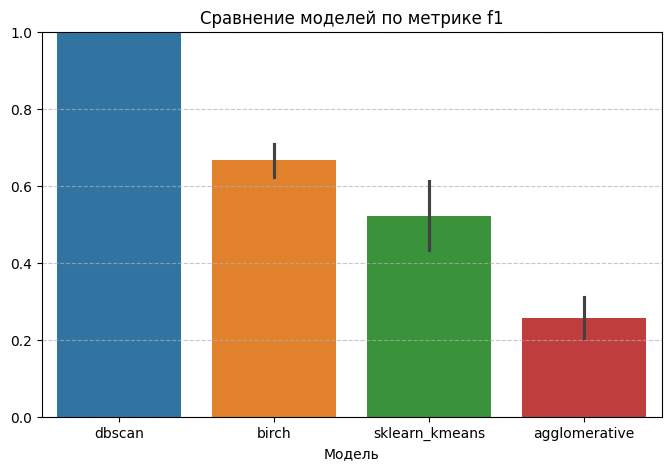

In [47]:
import seaborn as sns

metric_name = 'f1'
df = baseline_df.loc[baseline_df.metric == metric_name, ['model_name', 'value']].rename({'value':'Metric', 'model_name':'Model'}, axis=1)

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Metric', data=df, hue='Model')
plt.ylim(0, 1)
plt.title(f'Сравнение моделей по метрике {metric_name}')
plt.xlabel('Модель')
plt.ylabel('')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [2]:
# базовые одиночные методы выделения признаков
no_fe_extractor = Feature_extraction_method(no_fe, load_config_file('configs/manual_fe/no_fe.yaml'))
tsa_acf_extractor = Feature_extraction_method(tsa_acf, load_config_file('configs/manual_fe/tsa_acf.yaml'))
tsa_detrend_extractor = Feature_extraction_method(tsa_detrend, load_config_file('configs/manual_fe/tsa_detrend.yaml'))
stats_extractor = Feature_extraction_method(statistical_features, load_config_file('configs/manual_fe/statistical_features.yaml'))
paa_extractor = Feature_extraction_method(paa_features, load_config_file('configs/manual_fe/paa.yaml'))
stl_trend_extractor = Feature_extraction_method(stl_trend, load_config_file('configs/manual_fe/stl_decomposition.yaml'))

# peaks_extractor = Feature_extraction_method(signal_peaks_features, load_config_file('configs/manual_fe/signal_peaks.yaml'))
# stft_extractor = Feature_extraction_method(stft_features, load_config_file('configs/manual_fe/stft_features.yaml'))
# dft_components_extractor = Feature_extraction_method(dft_components, load_config_file('configs/manual_fe/dft_components.yaml'))
# dft_signal_extractor = Feature_extraction_method(dft_signal, load_config_file('configs/manual_fe/dft_signal.yaml'))
# dft_approximation_extractor = Feature_extraction_method(dft_approximation, load_config_file('configs/manual_fe/dft_approximation.yaml'))
# dwt_features_extractor = Feature_extraction_method(dwt_features, load_config_file('configs/manual_fe/dwt_features.yaml'))
# dwt_signal_extractor = Feature_extraction_method(dwt_signal, load_config_file('configs/manual_fe/dwt_signal.yaml'))
# stl_features_extractor = Feature_extraction_method(stl_features, load_config_file('configs/manual_fe/stl_features.yaml'))
# пайплайны одиночные методы выделения признаков
trend_pipelines = []

trend_pipelines.append(Feature_extractor_pipeline([no_fe_extractor]))
trend_pipelines.append(Feature_extractor_pipeline([tsa_acf_extractor]))
trend_pipelines.append(Feature_extractor_pipeline([tsa_detrend_extractor]))
trend_pipelines.append(Feature_extractor_pipeline([stats_extractor]))
trend_pipelines.append(Feature_extractor_pipeline([paa_extractor]))
trend_pipelines.append(Feature_extractor_pipeline([stl_trend_extractor]))

# pipelines.append(Feature_extractor_pipeline([peaks_extractor]))
# pipelines.append(Feature_extractor_pipeline([stft_extractor]))
# pipelines.append(Feature_extractor_pipeline([dft_components_extractor]))
# pipelines.append(Feature_extractor_pipeline([dft_approximation_extractor]))
# pipelines.append(Feature_extractor_pipeline([dwt_features_extractor]))
# pipelines.append(Feature_extractor_pipeline([dwt_signal_extractor]))
# pipelines.append(Feature_extractor_pipeline([stl_decomposition_extractor]))
# pipelines.append(Feature_extractor_pipeline([stl_features_extractor]))

# пайплайны двух методов выделения признаков

# пайплайны трех методов выделения признаков


In [ ]:
test_series = np.sin(np.linspace(0, 4 * np.pi, 100))
test_dt = np.array([test_series, test_series, test_series, test_series])

results = []
for pipeline in trend_pipelines:
    for n_segment in range(1,6,2):
        if n_segment == 1:
            use_segm = False
        results = pipeline.batch_extract(test_dt, use_segmentation=use_segm, n_segments=n_segment, verbose=False)
        # results.append(pipeline.batch_extract(test_dt, use_segmentation=use_segm, n_segments=n_segment, verbose=False))


e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimen

In [2]:
# len(results)
results[29][1]

NameError: name 'results' is not defined

In [6]:
full_grid = create_dist_params('configs/conditions/characteristic_grid.yaml', False)
# res_lt = get_dataset_inxs(full_grid, [[0,0]])

# print(res_lt)
full_grid[0]

{'noise_level': [0, 0],
 'sample_size': 50,
 'shifts': 0,
 'ts_length': 101,
 'value_scale': [0, 1]}

{'noise_level': [0.02, 0.05], 'sample_size': 100, 'shifts': 0, 'ts_length': 101, 'value_scale': [0, 1], 'n_cluster': 5}
{'noise_level': [0.02, 0.05], 'sample_size': 100, 'shifts': 0, 'ts_length': 101, 'value_scale': [0, 1], 'n_cluster': 5}


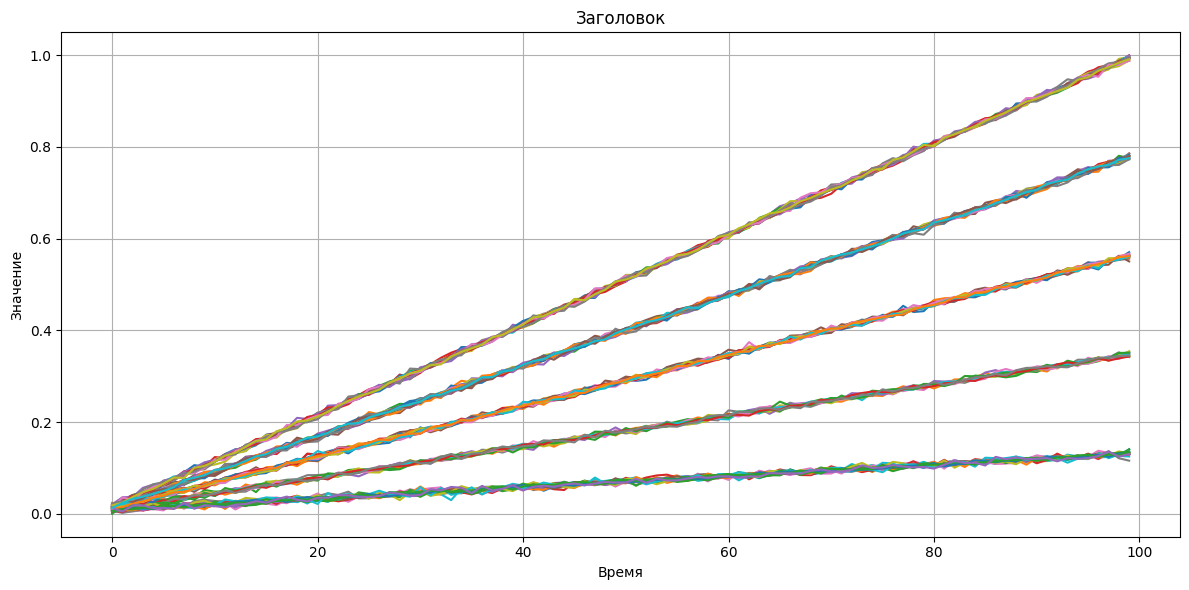

(100, 100)
0 - 0.24
1 - 0.15
2 - 0.19
3 - 0.22
4 - 0.20


In [ ]:
# выбор параметров
dist_params = full_grid[0]
print(dist_params)
dist_params['n_cluster'] = 5
dist_params['shifts'] = 0
dist_params['noise_level'] = [0.02, 0.05]
dist_params['sample_size'] = 100
dist_params['value_scale'] = [0, 1]
print(dist_params)

np.random.seed(21)
# генерация выборки
generator = linear_generator(dist_params['n_cluster'], dist_params['ts_length'])
harmonic_shift = harmonic_shift_generator(dist_params['ts_length'])
sample1, labels1 = create_dist(generator, dist_params, harmonic_shift, True, None)
sample_stats(sample1, labels1)

In [12]:
res_df = pd.DataFrame()

for pipeline in trend_pipelines:
    for n_segment in range(1,6,2):
        if n_segment == 1:
            use_segm = False
        features = pipeline.batch_extract(sample1, use_segmentation=use_segm, n_segments=n_segment, verbose=False)

        for feat_vector in features:
            X_train = np.asarray(feat_vector[0])
            y_train = np.asarray(labels1)
            fe_params = feat_vector[1]

            for model_name in ['dbscan', 'birch', 'sklearn_kmeans', 'agglomerative']:
                model_df = get_model(model_name, X_train, y_train, dist_params)
                model_df['model_name'] = model_name
                model_df['fe_method']= list(fe_params.keys())[0]
                model_df['fe_params']= '__'.join(['_'.join([str(k), str(v)]) for k,v in list(fe_params.values())[0].items()])
                model_df['segment'] = n_segment
                
                res_df = pd.concat([res_df, model_df])

res_df.to_excel('data/Synthetic_data/trend_result1.xlsx')

Grid Search Progress: 100%|██████████| 60/60 [00:00<00:00, 127.66it/s]
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:9

{'noise_level': [0.02, 0.05], 'sample_size': 100, 'shifts': 0, 'ts_length': 101, 'value_scale': [0, 1], 'n_cluster': 5}
{'noise_level': [0.02, 0.05], 'sample_size': 100, 'shifts': 0, 'ts_length': 101, 'value_scale': [0, 1], 'n_cluster': 10}


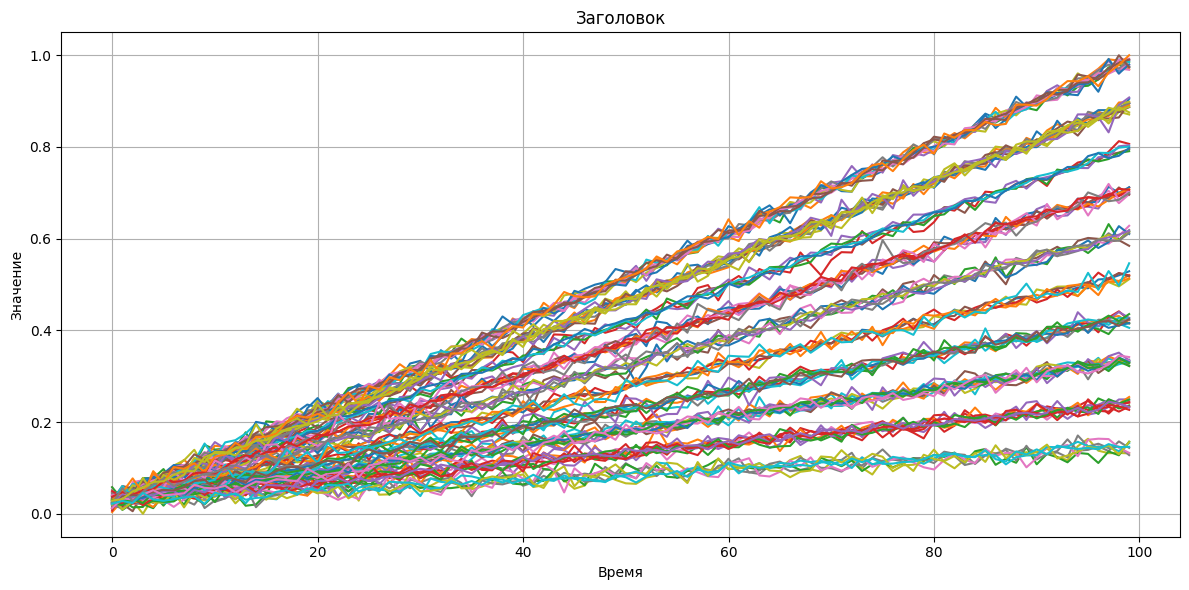

(100, 100)
0 - 0.11
1 - 0.08
2 - 0.13
3 - 0.10
4 - 0.07
5 - 0.08
6 - 0.10
7 - 0.06
8 - 0.13
9 - 0.14


In [13]:
# выбор параметров

dist_params = full_grid[0]
print(dist_params)
dist_params['n_cluster'] = 10
dist_params['shifts'] = 0
dist_params['noise_level'] = [0.02, 0.05]
dist_params['sample_size'] = 100
dist_params['value_scale'] = [0, 1]
print(dist_params)

np.random.seed(21)
# генерация выборки
generator = linear_generator(dist_params['n_cluster'], dist_params['ts_length'])
harmonic_shift = harmonic_shift_generator(dist_params['ts_length'])
sample1, labels1 = create_dist(generator, dist_params, harmonic_shift, True, None)
sample_stats(sample1, labels1)

In [14]:
res_df = pd.DataFrame()

for pipeline in trend_pipelines:
    for n_segment in range(1,6,2):
        if n_segment == 1:
            use_segm = False
        features = pipeline.batch_extract(sample1, use_segmentation=use_segm, n_segments=n_segment, verbose=False)

        for feat_vector in features:
            X_train = np.asarray(feat_vector[0])
            y_train = np.asarray(labels1)
            fe_params = feat_vector[1]

            for model_name in ['dbscan', 'birch', 'sklearn_kmeans', 'agglomerative']:
                model_df = get_model(model_name, X_train, y_train, dist_params)
                model_df['model_name'] = model_name
                model_df['fe_method']= list(fe_params.keys())[0]
                model_df['fe_params']= '__'.join(['_'.join([str(k), str(v)]) for k,v in list(fe_params.values())[0].items()])
                model_df['segment'] = n_segment
                
                res_df = pd.concat([res_df, model_df])

res_df.to_excel('data/Synthetic_data/trend_result2.xlsx')

Grid Search Progress:   0%|          | 0/10 [00:00<?, ?it/s]

Grid Search Progress: 100%|██████████| 60/60 [00:00<00:00, 110.77it/s]
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:9

In [66]:
res_df

,parameter,metric,value,model_name,fe_method,fe_params,segment
0,"{'eps': 0.05, 'min_samples': 1}",silhouette,NaN,dbscan,no_fe,,1
1,"{'eps': 0.05, 'min_samples': 1}",davies_bouldin_score,NaN,dbscan,no_fe,,1
2,"{'eps': 0.05, 'min_samples': 1}",calinski_harabasz_score,NaN,dbscan,no_fe,,1
3,"{'eps': 0.05, 'min_samples': 1}",nmi,0.419341,dbscan,no_fe,,1
4,"{'eps': 0.05, 'min_samples': 1}",ari,0.000000,dbscan,no_fe,,1
...,...,...,...,...,...,...,...
319,"{'linkage': 'single', 'metric': 'l2', 'n_clusters': 4}",ari,-0.194690,agglomerative,stl_trend,period_10,5
320,"{'linkage': 'single', 'metric': 'l2', 'n_clusters': 4}",accuracy,0.400000,agglomerative,stl_trend,period_10,5
321,"{'linkage': 'single', 'metric': 'l2', 'n_clusters': 4}",precision,0.142857,agglomerative,stl_trend,period_10,5
322,"{'linkage': 'single', 'metric': 'l2', 'n_clusters': 4}",recall,0.142857,agglomerative,stl_trend,period_10,5


In [ ]:
res_df = get_model('dbscan', results[0][0], [0,0,0,1])
res_df['fe_method']= list(results[0][1].keys())[0]
res_df['fe_params']= '__'.join(['_'.join([str(k), str(v)]) for k,v in list(results[0][1].values())[0].items()])
res_df

Grid Search Progress: 100%|██████████| 100/100 [00:00<00:00, 100.48it/s]


,parameter,metric,value,fe_method,fe_params
0,"{'eps': 0.05, 'min_samples': 1}",silhouette,NaN,dft_components,fs_100__n_freqs_5
1,"{'eps': 0.05, 'min_samples': 1}",davies_bouldin_score,NaN,dft_components,fs_100__n_freqs_5
2,"{'eps': 0.05, 'min_samples': 1}",calinski_harabasz_score,NaN,dft_components,fs_100__n_freqs_5
3,"{'eps': 0.05, 'min_samples': 1}",nmi,0.0,dft_components,fs_100__n_freqs_5
4,"{'eps': 0.05, 'min_samples': 1}",ari,0.0,dft_components,fs_100__n_freqs_5
...,...,...,...,...,...
895,"{'eps': 4.0, 'min_samples': 96}",ari,0.0,dft_components,fs_100__n_freqs_5
896,"{'eps': 4.0, 'min_samples': 96}",accuracy,0.0,dft_components,fs_100__n_freqs_5
897,"{'eps': 4.0, 'min_samples': 96}",precision,0.0,dft_components,fs_100__n_freqs_5
898,"{'eps': 4.0, 'min_samples': 96}",recall,0.0,dft_components,fs_100__n_freqs_5


In [15]:
dft_components(test_series[:25], n_freqs=10)

array([ 0.06226375, -3.02081379,  0.07410061, -3.00452926,  0.09240078,
       -2.99810041,  0.12154542, -3.00093745,  0.17088794, -3.01195155,
        0.26324628, -3.02980887,  0.46720868, -3.05309366,  1.08051788,
       -3.08039463,  5.40190645, -3.11033876, 15.74708115, -0.        ])

In [14]:
fe1.param_grid

e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimensional timeseries
  warnings.warn(
e:\GitHubProjects\autolabeling_time_series_data\.basic_312\Lib\site-packages\tslearn\utils\utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 1 1-dimen

grid_search dict_keys(['model', 'param_grid']) {'model': 'DBSCAN_model', 'param_grid': {'eps': {'type': 'Real', 'low': 0.05, 'high': 4.0, 'step': 0.05}, 'min_samples': {'type': 'Integer', 'low': 10, 'high': 100, 'step': 5}}}


Grid Search Progress: 100%|██████████| 95/95 [00:21<00:00,  4.46it/s]


grid_search dict_keys(['model', 'param_grid']) {'model': 'BIRCH_model', 'param_grid': {'threshold': {'type': 'Real', 'low': 0.1, 'high': 1.1, 'step': 0.1}, 'branching_factor': {'type': 'Integer', 'low': 10, 'high': 100, 'step': 10}, 'n_clusters': {'type': 'Integer', 'low': 2, 'high': 7}}}


Grid Search Progress: 100%|██████████| 300/300 [01:09<00:00,  4.34it/s]


grid_search dict_keys(['model', 'param_grid']) {'model': 'Sklearn_kmeans_model', 'param_grid': {'n_clusters': {'type': 'Integer', 'low': 3, 'high': 7, 'step': 1}, 'init': {'type': 'Categorical', 'values': ['k-means++', 'random']}, 'n_init': {'type': 'Integer', 'low': 5, 'high': 20, 'step': 10}, 'max_iter': {'type': 'Integer', 'low': 100, 'high': 300, 'step': 100}}}


Grid Search Progress: 100%|██████████| 60/60 [00:15<00:00,  3.75it/s]


grid_search dict_keys(['model', 'param_grid']) {'model': 'AC_model', 'param_grid': {'n_clusters': {'type': 'Integer', 'low': 3, 'high': 7}, 'linkage': {'type': 'Categorical', 'values': ['complete', 'average', 'single']}, 'metric': {'type': 'Categorical', 'values': ['euclidean', 'cosine', 'l1', 'l2']}}}


Grid Search Progress: 100%|██████████| 60/60 [00:13<00:00,  4.60it/s]


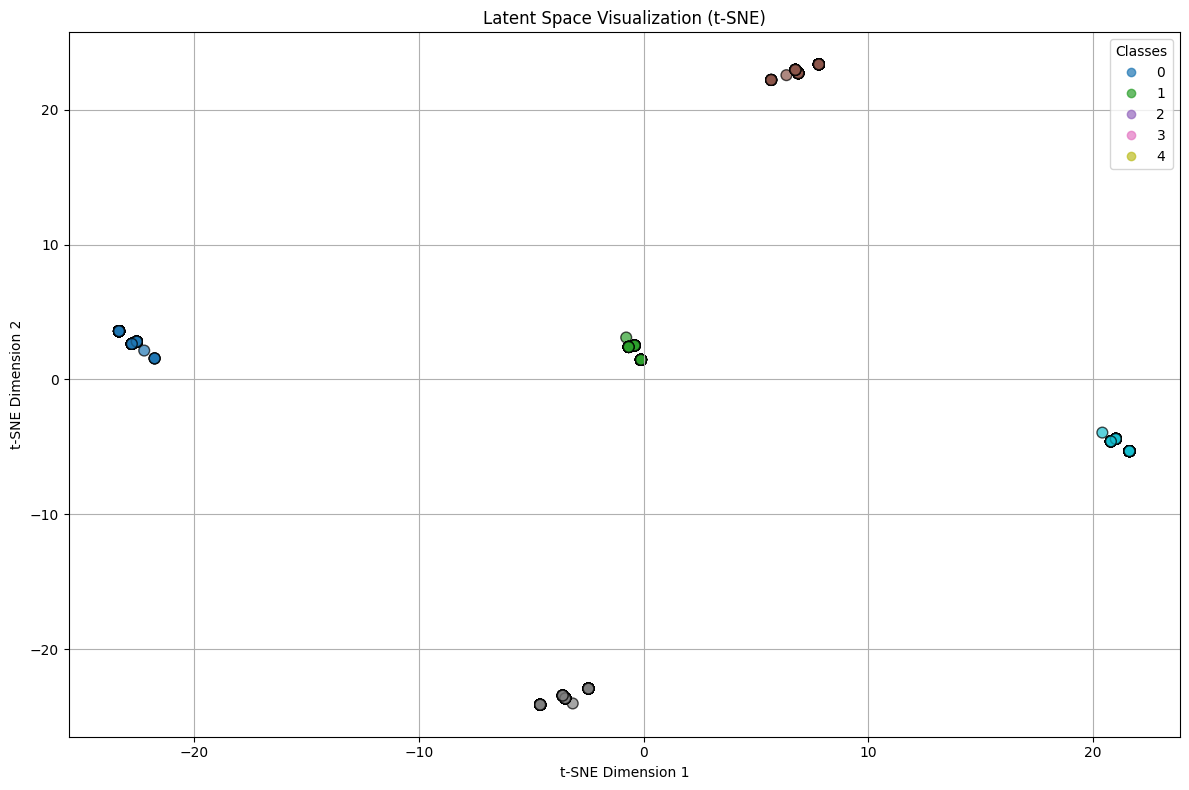

In [136]:
fe_method_name = 'paa'
dir_path = 'data/Synthetic_data/trash1'
# выделение признаков
X_train = []
for row in sample1:
    # X_train.append(row)
    # X_train.append(tsa_detrend(row))
    # X_train.append(tsa_acf(row))
    X_train.append(paa_features(row, 5))

y_train = np.asarray(labels1)
X_train = np.asarray(X_train)

res_df = pd.DataFrame()

for model_name in ['dbscan', 'birch', 'sklearn_kmeans', 'agglomerative']:
    model_df = get_model(model_name, X_train, y_train, dist_params)
    model_df['name'] = model_name
    res_df = pd.concat([res_df, model_df])

visualize_clusters(X_train, y_train, dir_path)
res = visualize_latent_space(X_train, y_train, None)
# plot_series([row for row in X_train], show_legend=False)

res_df.to_excel(f'{dir_path}/{fe_method_name}.xlsx')

In [137]:
res_df.loc[res_df.metric == 'f1'].sort_values('value', ascending=False)

,parameter,metric,value,name
152,"{'init': 'k-means++', 'max_iter': 200, 'n_clusters': 6, 'n_init': 5}",f1,1.000000,sklearn_kmeans
476,"{'linkage': 'single', 'metric': 'l1', 'n_clusters': 5}",f1,1.000000,agglomerative
485,"{'linkage': 'single', 'metric': 'l1', 'n_clusters': 6}",f1,0.832965,agglomerative
521,"{'init': 'random', 'max_iter': 300, 'n_clusters': 6, 'n_init': 15}",f1,0.728239,sklearn_kmeans
494,"{'linkage': 'single', 'metric': 'l1', 'n_clusters': 7}",f1,0.713654,agglomerative
...,...,...,...,...
512,"{'init': 'random', 'max_iter': 300, 'n_clusters': 6, 'n_init': 5}",f1,0.000000,sklearn_kmeans
530,"{'init': 'random', 'max_iter': 300, 'n_clusters': 7, 'n_init': 5}",f1,0.000000,sklearn_kmeans
269,"{'init': 'k-means++', 'max_iter': 300, 'n_clusters': 7, 'n_init': 15}",f1,0.000000,sklearn_kmeans
233,"{'linkage': 'average', 'metric': 'cosine', 'n_clusters': 3}",f1,0.000000,agglomerative


In [132]:
model_df.loc[model_df.metric == 'f1'].sort_values('value', ascending=False)

,parameter,metric,value,name
62,"{'linkage': 'complete', 'metric': 'cosine', 'n_clusters': 4}",f1,0.287026,agglomerative
71,"{'linkage': 'complete', 'metric': 'cosine', 'n_clusters': 5}",f1,0.286806,agglomerative
53,"{'linkage': 'complete', 'metric': 'cosine', 'n_clusters': 3}",f1,0.284082,agglomerative
80,"{'linkage': 'complete', 'metric': 'cosine', 'n_clusters': 6}",f1,0.238821,agglomerative
89,"{'linkage': 'complete', 'metric': 'cosine', 'n_clusters': 7}",f1,0.204545,agglomerative
386,"{'linkage': 'single', 'metric': 'euclidean', 'n_clusters': 5}",f1,0.200000,agglomerative
476,"{'linkage': 'single', 'metric': 'l1', 'n_clusters': 5}",f1,0.200000,agglomerative
116,"{'linkage': 'complete', 'metric': 'l1', 'n_clusters': 5}",f1,0.200000,agglomerative
296,"{'linkage': 'average', 'metric': 'l1', 'n_clusters': 5}",f1,0.200000,agglomerative
521,"{'linkage': 'single', 'metric': 'l2', 'n_clusters': 5}",f1,0.200000,agglomerative


In [ ]:


def visualize_clusters(X, y, save_path):
    for val in np.unique(y):
        plot_series(X[y == val].tolist(), show_legend=False, plot_title=f'Cluster {val}', save_path=f"{save_path}/Cluster {val}.png")


def make_pipeline(X, prep_funcs):
    X_prep = []
    for row in X:
        new_row = row.copy()
        for prep_func in prep_funcs:
            prep_model = TS_feature_extractor(prep_func)
            res = prep_model.extract(new_row)
            new_row = res
        X_prep.append(new_row)  
    return np.asarray(X_prep)


def get_segments(data: np.ndarray, n_segments: int = None, segment_size: int = None) -> list:
    length = len(data)

    if n_segments is not None:
        segment_size = length // n_segments
    elif segment_size is not None:
        n_segments = length // segment_size
    else:
        raise ValueError("Укажите либо n_segments, либо segment_size")

    remainder = length % n_segments
    if remainder != 0:
        print(f"Длина массива не делится на {n_segments}, последние {remainder} элементов будут проигнорированы.")

    segments = []
    for i in range(n_segments):
        start = i * segment_size
        end = start + segment_size
        segments.append(data[start:end])

    return segments


def make_segm_pipeline(X, prep_funcs, n_segments, segm_use:list=None):
    X_prep = []
    if segm_use is None:
        segm_use = list(range(n_segments))
        
    for row in X:
        new_row = row.copy()
        segments = [item for inx, item in enumerate(get_segments(new_row, n_segments)) if inx in segm_use]
        res = make_pipeline(segments, prep_funcs)
        new_row = np.concatenate(res)
    X_prep.append(new_row)  
    return np.asarray(X_prep)




def visualize_latent_space(train_latents, train_labels, model_save_path):
    """
    Визуализация латентного пространства с помощью t-SNE.
    Объединяет train и val для проецирования, но различает их на графике.
    """

    # Объединяем все данные для t-SNE
    combined = np.concatenate([train_latents], axis=0)
    labels_combined = np.concatenate([train_labels], axis=0)

    # Создаем маски для train/val
    train_mask = np.array([True]*train_latents.shape[0])
    # Применяем t-SNE ко всем данным сразу
    tsne = TSNE(n_components=2, random_state=42, init='random', perplexity=30)
    latents_2d = tsne.fit_transform(combined)

    # Разделяем результаты обратно
    train_2d = latents_2d[train_mask]

    # Визуализация
    plt.figure(figsize=(12, 8))

    # Точки из train
    scatter_train = plt.scatter(train_2d[:, 0], train_2d[:, 1], 
                                c=train_labels, cmap='tab10', s=60, 
                                label='Train', edgecolor='k', alpha=0.7)

    # Легенда
    unique_labels = np.unique(labels_combined)
    handles, _ = scatter_train.legend_elements(prop="colors", num=len(unique_labels))
    plt.legend(handles, unique_labels, title="Classes")

    plt.title("Latent Space Visualization (t-SNE) - Train")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.grid(True)
    plt.tight_layout()
    if model_save_path is not None:
        plt.savefig(model_save_path)
        plt.close()
    else:
        plt.show()



# synthetic 

In [3]:
from src.generation.ts_generators import *  
from src.generation.ts_noise_generators import *  
from src.generation.ts_creation import *
from src.utils import plot_series, plot_series_grid

In [4]:
clusters_num = 2
step = 0.05
sample_q = 100
trend_config = 'configs/trends/linear_trend2_101.yaml'


trend_gen = TS_generator(linear_trend, trend_config)

grid = np.linspace(trend_gen.config['slope_d'], trend_gen.config['slope_u'], clusters_num)

X_train = []
lbls = []

for inx, item in enumerate(grid):
    print(inx, item)
    trend_gen.config['slope_d'] = item - step
    trend_gen.config['slope_u'] = item + step
    trend_gen.config['slope_q'] = 1
    
    sample = trend_gen.generate()[0]
    noise = Noise_generator(sample, normal_noise, 'configs/noise/normal_05.yaml')
    
    for _ in range(int(sample_q/clusters_num)):
        cl1 = TS_merger()
        block1 = TS_block(trend=trend_gen, noise=noise)
        cl1.add_block(block1)

        X_train.append(cl1.generate())
         
    lbls += [inx+1] * int(sample_q/clusters_num)

X_train = np.array(X_train)
lbls = np.array(lbls)

print(X_train.shape, lbls.shape)

0 0.01
1 0.1
(100, 100) (100,)


In [5]:
# methods = [Feature_extraction_method(statistical_features, 'configs/manual_fe/statistical_features.yaml'), Feature_extraction_method(statistical_features, 'configs/manual_fe/tsa_detrend.yaml')]
methods = [Feature_extraction_method(tsa_detrend, 'configs/manual_fe/tsa_detrend.yaml')]
pipeline = Feature_extractor_pipeline(methods)

result = pipeline.batch_extract(X_train, 'grid')

In [6]:
f1_scores = []
nmi_scores = []
ari_scores = []
si_scores = []

y_train = lbls

for i, item in enumerate(result):
    res = get_model('sklearn_kmeans', item, y_train)
    # visualize_latent_space(result[0], y_train, 'experiments/manual_methods/Chinatown/no_techniques.png')
    si_scores.append(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).iloc[0,-1])
    nmi_scores.append(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).iloc[0,-1])
    ari_scores.append(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).iloc[0,-1])
    f1_scores.append(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).iloc[0,-1])

plot_series_grid([f1_scores, nmi_scores, ari_scores, si_scores], ['f1_score', 'ARI', 'NMI', 'Silhouette_score'])

Grid Search Progress:   0%|          | 0/60 [00:00<?, ?it/s]


AttributeError: 'StandardScaler' object has no attribute 'normalize'

# real data

In [3]:
X_train, X_test, y_train, y_test = prepare_data('Chinatown')

fe_stl = Feature_extraction_method(stl_features, "configs/manual_fe/stl.yaml")
stats = Feature_extraction_method(statistical_features, 'configs/manual_fe/statistical_features.yaml')
pipeline = Feature_extractor_pipeline([fe_stl, stats])
# results = pipeline.extract_all(X_train[0])
results_grid = pipeline.batch_extract(X_train[:5], 'grid')
results_con = pipeline.batch_extract(X_train[:5], 'concat')

Old Classes: [1 2]
New Classes: [0 1]
(290, 24) (73, 24)
[0 1]
1    0.713793
0    0.286207
Name: proportion, dtype: float64
1    0.712329
0    0.287671
Name: proportion, dtype: float64


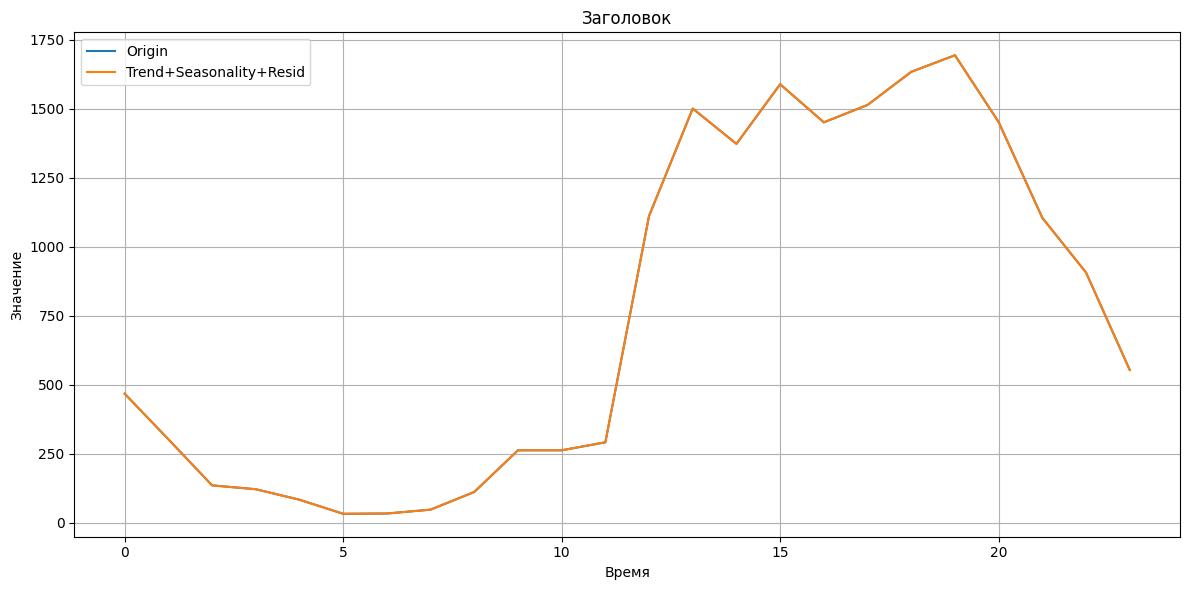

In [61]:
res_dec = stl_decomposition(X_train[0], period=4)
plot_series([X_train[0], res_dec[0]+res_dec[1]+res_dec[2]], ['Origin','Trend+Seasonality+Resid'])

In [20]:
results_grid[0][0][0] == np.concatenate([
results_con[0][0][:5], 
results_con[0][0][100:]])

result = pipeline.batch_extract(X_train, 'grid')[0]

(290, 11)


Grid Search Progress: 100%|██████████| 60/60 [00:03<00:00, 19.22it/s]


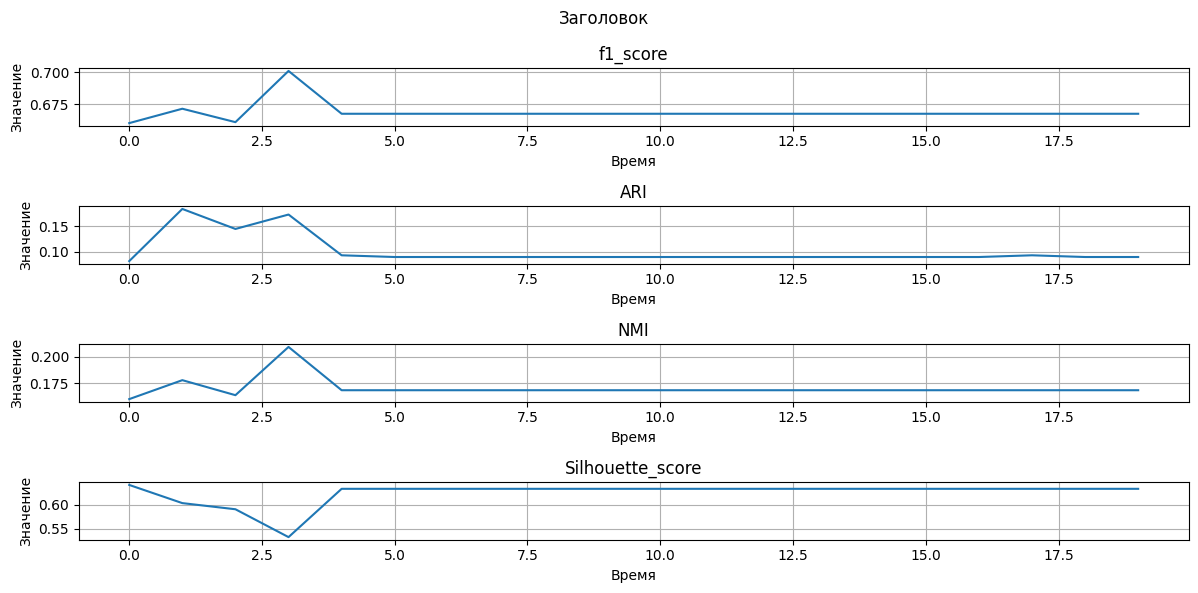

In [33]:
print(result[0].shape)

f1_scores = []
nmi_scores = []
ari_scores = []
si_scores = []

for i, item in enumerate(result):
    res = get_model('sklearn_kmeans', item, y_train)
    # visualize_latent_space(result[0], y_train, 'experiments/manual_methods/Chinatown/no_techniques.png')
    si_scores.append(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).iloc[0,-1])
    nmi_scores.append(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).iloc[0,-1])
    ari_scores.append(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).iloc[0,-1])
    f1_scores.append(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).iloc[0,-1])

plot_series_grid([f1_scores, nmi_scores, ari_scores, si_scores], ['f1_score', 'ARI', 'NMI', 'Silhouette_score'])

In [35]:
X_train, X_test, y_train, y_test = prepare_data('MelbournePedestrian')
len([np.mean(X_train[y_train == y_val], axis=0) for y_val in np.unique(y_train)]), len(np.unique(y_train).tolist())
# np.mean(X_train, axis=2)
# plot_series(np.array([np.mean(X_train[y_train == y_val], axis=0) for y_val in np.unique(y_train)]), np.unique(y_train).tolist())
# print(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).head(1))
# print(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).head(1))
# print(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).head(1))
# print(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).head(1))


Old Classes: [ 1  2  3  4  5  6  7  8  9 10]
New Classes: [0 1 2 3 4 5 6 7 8 9]
(2765, 24) (692, 24)
[0 1 2 3 4 5 6 7 8 9]
3    0.105244
4    0.104882
9    0.104882
6    0.104882
0    0.104882
5    0.103797
1    0.103074
2    0.098011
7    0.086799
8    0.083544
Name: proportion, dtype: float64
9    0.105491
0    0.105491
6    0.105491
4    0.105491
5    0.104046
3    0.104046
1    0.102601
2    0.098266
7    0.086705
8    0.082370
Name: proportion, dtype: float64


(10, 10)

In [14]:
X_train, X_test, y_train, y_test = prepare_data('Chinatown')

# X_train = use_scaler(X_train)
# X_test = use_scaler(X_test)

visualize_clusters(X_train, y_train, 'experiments/manual_methods/Chinatown')

res = get_model('sklearn_kmeans', X_train, y_train)
visualize_latent_space(X_train, y_train, 'experiments/manual_methods/Chinatown/no_techniques.png')

print(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).head())

X_train_new = make_pipeline(X_train, [tsa_detrend])
res = get_model('sklearn_kmeans', X_train_new, y_train)
visualize_latent_space(X_train_new, y_train,'experiments/manual_methods/Chinatown/detrend.png')

print(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).head())

X_train_new = make_pipeline(X_train, [tsa_detrend, dft_signal])
res = get_model('sklearn_kmeans', X_train_new, y_train)
visualize_latent_space(X_train_new, y_train,'experiments/manual_methods/Chinatown/detrend_dft_components.png')

print(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).head())


Old Classes: [1 2]
New Classes: [0 1]
(290, 24) (73, 24)
[0 1]
1    0.713793
0    0.286207
Name: proportion, dtype: float64
1    0.712329
0    0.287671
Name: proportion, dtype: float64


Grid Search Progress: 100%|██████████| 60/60 [00:03<00:00, 17.21it/s]


                                                                 parameter  \
0     {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 5}   
99   {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 2, 'n_init': 15}   
459     {'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 15}   
450      {'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 5}   
369     {'init': 'random', 'max_iter': 200, 'n_clusters': 2, 'n_init': 15}   

         metric     value  
0    silhouette  0.463283  
99   silhouette  0.463283  
459  silhouette  0.463283  
450  silhouette  0.463283  
369  silhouette  0.463283  
                                                                 parameter  \
75    {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 6, 'n_init': 5}   
174  {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 6, 'n_init': 15}   
246  {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 5, 'n_init': 15}   
66   {'init': 'k-means++', 'max_iter': 100, 'n_clus

Grid Search Progress: 100%|██████████| 60/60 [00:03<00:00, 18.40it/s]


                                                                 parameter  \
0     {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 5}   
99   {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 2, 'n_init': 15}   
459     {'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 15}   
450      {'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 5}   
369     {'init': 'random', 'max_iter': 200, 'n_clusters': 2, 'n_init': 15}   

         metric     value  
0    silhouette  0.333424  
99   silhouette  0.333424  
459  silhouette  0.333424  
450  silhouette  0.333424  
369  silhouette  0.333424  
                                                                 parameter  \
3     {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 5}   
102  {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 2, 'n_init': 15}   
462     {'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 15}   
453      {'init': 'random', 'max_iter': 300, 'n_clu

Grid Search Progress: 100%|██████████| 60/60 [00:03<00:00, 17.38it/s]


                                                                 parameter  \
0     {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 5}   
99   {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 2, 'n_init': 15}   
459     {'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 15}   
450      {'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 5}   
369     {'init': 'random', 'max_iter': 200, 'n_clusters': 2, 'n_init': 15}   

         metric     value  
0    silhouette  0.305999  
99   silhouette  0.305999  
459  silhouette  0.305999  
450  silhouette  0.305999  
369  silhouette  0.305999  
                                                                 parameter  \
381      {'init': 'random', 'max_iter': 200, 'n_clusters': 3, 'n_init': 5}   
300     {'init': 'random', 'max_iter': 100, 'n_clusters': 3, 'n_init': 15}   
201   {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 3, 'n_init': 5}   
210  {'init': 'k-means++', 'max_iter': 300, 'n_clus

In [22]:
res#.metric.unique()

,parameter,metric,value
0,"{'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 5}",silhouette,0.630510
1,"{'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 5}",davies_bouldin_score,0.605933
2,"{'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 5}",calinski_harabasz_score,6440.692877
3,"{'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 5}",nmi,0.329896
4,"{'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 5}",ari,0.134839
...,...,...,...
535,"{'init': 'random', 'max_iter': 300, 'n_clusters': 6, 'n_init': 15}",ari,0.294905
536,"{'init': 'random', 'max_iter': 300, 'n_clusters': 6, 'n_init': 15}",accuracy,0.030741
537,"{'init': 'random', 'max_iter': 300, 'n_clusters': 6, 'n_init': 15}",precision,0.031495
538,"{'init': 'random', 'max_iter': 300, 'n_clusters': 6, 'n_init': 15}",recall,0.030015


In [21]:
res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False)

,parameter,metric,value
0,"{'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 5}",silhouette,0.630510
99,"{'init': 'k-means++', 'max_iter': 200, 'n_clusters': 2, 'n_init': 15}",silhouette,0.630510
459,"{'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 15}",silhouette,0.630510
450,"{'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 5}",silhouette,0.630510
369,"{'init': 'random', 'max_iter': 200, 'n_clusters': 2, 'n_init': 15}",silhouette,0.630510
360,"{'init': 'random', 'max_iter': 200, 'n_clusters': 2, 'n_init': 5}",silhouette,0.630510
279,"{'init': 'random', 'max_iter': 100, 'n_clusters': 2, 'n_init': 15}",silhouette,0.630510
9,"{'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 15}",silhouette,0.630510
189,"{'init': 'k-means++', 'max_iter': 300, 'n_clusters': 2, 'n_init': 15}",silhouette,0.630510
180,"{'init': 'k-means++', 'max_iter': 300, 'n_clusters': 2, 'n_init': 5}",silhouette,0.630510


In [18]:
X_train, X_test, y_train, y_test = prepare_data('MelbournePedestrian')

visualize_clusters(X_train, y_train, 'experiments/manual_methods/MelbournePedestrian')

res = get_model('sklearn_kmeans', X_train, y_train)
visualize_latent_space(X_train, y_train, 'experiments/manual_methods/MelbournePedestrian/no_techniques.png')

print(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).head())

X_train_new = make_pipeline(X_train, [tsa_detrend])
res = get_model('sklearn_kmeans', X_train_new, y_train)
visualize_latent_space(X_train_new, y_train,'experiments/manual_methods/MelbournePedestrian/detrend.png')

print(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).head())

X_train_new = make_pipeline(X_train, [tsa_detrend, dft_signal])
res = get_model('sklearn_kmeans', X_train_new, y_train)
visualize_latent_space(X_train_new, y_train,'experiments/manual_methods/MelbournePedestrian/detrend_dft_components.png')

print(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).head())

X_train_new = make_pipeline(X_train, [signal_peaks_features])
res = get_model('sklearn_kmeans', X_train_new, y_train)
visualize_latent_space(X_train_new, y_train,'experiments/manual_methods/MelbournePedestrian/signal_peaks_features.png')

print(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).head())


Old Classes: [ 1  2  3  4  5  6  7  8  9 10]
New Classes: [0 1 2 3 4 5 6 7 8 9]
(2765, 24) (692, 24)
[0 1 2 3 4 5 6 7 8 9]
3    0.105244
4    0.104882
9    0.104882
6    0.104882
0    0.104882
5    0.103797
1    0.103074
2    0.098011
7    0.086799
8    0.083544
Name: proportion, dtype: float64
9    0.105491
0    0.105491
6    0.105491
4    0.105491
5    0.104046
3    0.104046
1    0.102601
2    0.098266
7    0.086705
8    0.082370
Name: proportion, dtype: float64


Grid Search Progress: 100%|██████████| 60/60 [00:11<00:00,  5.14it/s]


                                                                 parameter  \
198   {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 3, 'n_init': 5}   
18    {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 3, 'n_init': 5}   
477     {'init': 'random', 'max_iter': 300, 'n_clusters': 3, 'n_init': 15}   
207  {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 3, 'n_init': 15}   
108   {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 3, 'n_init': 5}   

         metric     value  
198  silhouette  0.566540  
18   silhouette  0.566540  
477  silhouette  0.565681  
207  silhouette  0.565681  
108  silhouette  0.565681  
                                                                 parameter  \
345      {'init': 'random', 'max_iter': 100, 'n_clusters': 6, 'n_init': 5}   
264  {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 6, 'n_init': 15}   
174  {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 6, 'n_init': 15}   
534     {'init': 'random', 'max_iter': 300, 'n_clus

Grid Search Progress: 100%|██████████| 60/60 [00:11<00:00,  5.28it/s]


                                                                 parameter  \
198   {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 3, 'n_init': 5}   
108   {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 3, 'n_init': 5}   
18    {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 3, 'n_init': 5}   
27   {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 3, 'n_init': 15}   
477     {'init': 'random', 'max_iter': 300, 'n_clusters': 3, 'n_init': 15}   

         metric     value  
198  silhouette  0.617216  
108  silhouette  0.617216  
18   silhouette  0.617216  
27   silhouette  0.617216  
477  silhouette  0.617216  
                                                                parameter  \
345     {'init': 'random', 'max_iter': 100, 'n_clusters': 6, 'n_init': 5}   
435     {'init': 'random', 'max_iter': 200, 'n_clusters': 6, 'n_init': 5}   
75   {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 6, 'n_init': 5}   
534    {'init': 'random', 'max_iter': 300, 'n_clusters'

Grid Search Progress: 100%|██████████| 60/60 [00:12<00:00,  4.83it/s]


                                                                 parameter  \
198   {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 3, 'n_init': 5}   
297     {'init': 'random', 'max_iter': 100, 'n_clusters': 3, 'n_init': 15}   
18    {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 3, 'n_init': 5}   
27   {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 3, 'n_init': 15}   
468      {'init': 'random', 'max_iter': 300, 'n_clusters': 3, 'n_init': 5}   

         metric     value  
198  silhouette  0.559079  
297  silhouette  0.559079  
18   silhouette  0.559079  
27   silhouette  0.559079  
468  silhouette  0.559079  
                                                                parameter  \
354    {'init': 'random', 'max_iter': 100, 'n_clusters': 6, 'n_init': 15}   
345     {'init': 'random', 'max_iter': 100, 'n_clusters': 6, 'n_init': 5}   
435     {'init': 'random', 'max_iter': 200, 'n_clusters': 6, 'n_init': 5}   
534    {'init': 'random', 'max_iter': 300, 'n_clusters'

Grid Search Progress: 100%|██████████| 60/60 [00:11<00:00,  5.22it/s]


                                                                 parameter  \
0     {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 5}   
99   {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 2, 'n_init': 15}   
459     {'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 15}   
450      {'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 5}   
369     {'init': 'random', 'max_iter': 200, 'n_clusters': 2, 'n_init': 15}   

         metric    value  
0    silhouette  0.63051  
99   silhouette  0.63051  
459  silhouette  0.63051  
450  silhouette  0.63051  
369  silhouette  0.63051  
                                                                 parameter  \
444     {'init': 'random', 'max_iter': 200, 'n_clusters': 6, 'n_init': 15}   
435      {'init': 'random', 'max_iter': 200, 'n_clusters': 6, 'n_init': 5}   
525      {'init': 'random', 'max_iter': 300, 'n_clusters': 6, 'n_init': 5}   
165   {'init': 'k-means++', 'max_iter': 200, 'n_clusters'

In [ ]:
X_train, X_test, y_train, y_test = prepare_data('MelbournePedestrian')
X_train = use_scaler(X_train)

visualize_clusters(X_train, y_train, 'experiments/manual_methods/MelbournePedestrian_scaled')

res = get_model('sklearn_kmeans', X_train, y_train)
visualize_latent_space(X_train, y_train, 'experiments/manual_methods/MelbournePedestrian_scaled/no_techniques.png')

print(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).head())

X_train_new = make_pipeline(X_train, [tsa_detrend])
res = get_model('sklearn_kmeans', X_train_new, y_train)
visualize_latent_space(X_train_new, y_train,'experiments/manual_methods/MelbournePedestrian_scaled/detrend.png')

print(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).head())

X_train_new = make_pipeline(X_train, [tsa_detrend, dft_signal])
res = get_model('sklearn_kmeans', X_train_new, y_train)
visualize_latent_space(X_train_new, y_train,'experiments/manual_methods/MelbournePedestrian_scaled/detrend_dft_components.png')

print(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).head())


X_train_new = make_pipeline(X_train, [signal_peaks_features])
res = get_model('sklearn_kmeans', X_train_new, y_train)
visualize_latent_space(X_train_new, y_train,'experiments/manual_methods/MelbournePedestrian_scaled/signal_peaks_features.png')

print(res.loc[res.metric == 'silhouette'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'nmi'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'ari'].sort_values('value', ascending=False).head())
print(res.loc[res.metric == 'f1'].sort_values('value', ascending=False).head())


Old Classes: [ 1  2  3  4  5  6  7  8  9 10]
New Classes: [0 1 2 3 4 5 6 7 8 9]
(2765, 24) (692, 24)
[0 1 2 3 4 5 6 7 8 9]
3    0.105244
4    0.104882
9    0.104882
6    0.104882
0    0.104882
5    0.103797
1    0.103074
2    0.098011
7    0.086799
8    0.083544
Name: proportion, dtype: float64
9    0.105491
0    0.105491
6    0.105491
4    0.105491
5    0.104046
3    0.104046
1    0.102601
2    0.098266
7    0.086705
8    0.082370
Name: proportion, dtype: float64


Grid Search Progress: 100%|██████████| 60/60 [00:12<00:00,  4.87it/s]


                                                                 parameter  \
405     {'init': 'random', 'max_iter': 200, 'n_clusters': 4, 'n_init': 15}   
225  {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 4, 'n_init': 15}   
126   {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 4, 'n_init': 5}   
135  {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 4, 'n_init': 15}   
27   {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 3, 'n_init': 15}   

         metric     value  
405  silhouette  0.507677  
225  silhouette  0.507091  
126  silhouette  0.507091  
135  silhouette  0.507091  
27   silhouette  0.506645  
                                                              parameter  \
444  {'init': 'random', 'max_iter': 200, 'n_clusters': 6, 'n_init': 15}   
354  {'init': 'random', 'max_iter': 100, 'n_clusters': 6, 'n_init': 15}   
345   {'init': 'random', 'max_iter': 100, 'n_clusters': 6, 'n_init': 5}   
525   {'init': 'random', 'max_iter': 300, 'n_clusters': 6, 'n_i

Grid Search Progress: 100%|██████████| 60/60 [00:12<00:00,  4.93it/s]


                                                                 parameter  \
396      {'init': 'random', 'max_iter': 200, 'n_clusters': 4, 'n_init': 5}   
495     {'init': 'random', 'max_iter': 300, 'n_clusters': 4, 'n_init': 15}   
405     {'init': 'random', 'max_iter': 200, 'n_clusters': 4, 'n_init': 15}   
135  {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 4, 'n_init': 15}   
126   {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 4, 'n_init': 5}   

         metric     value  
396  silhouette  0.497733  
495  silhouette  0.497595  
405  silhouette  0.497595  
135  silhouette  0.497595  
126  silhouette  0.497595  
                                                              parameter  \
435   {'init': 'random', 'max_iter': 200, 'n_clusters': 6, 'n_init': 5}   
534  {'init': 'random', 'max_iter': 300, 'n_clusters': 6, 'n_init': 15}   
525   {'init': 'random', 'max_iter': 300, 'n_clusters': 6, 'n_init': 5}   
354  {'init': 'random', 'max_iter': 100, 'n_clusters': 6, 'n_in

Grid Search Progress: 100%|██████████| 60/60 [00:12<00:00,  4.75it/s]


                                                                parameter  \
126  {'init': 'k-means++', 'max_iter': 200, 'n_clusters': 4, 'n_init': 5}   
468     {'init': 'random', 'max_iter': 300, 'n_clusters': 3, 'n_init': 5}   
477    {'init': 'random', 'max_iter': 300, 'n_clusters': 3, 'n_init': 15}   
378     {'init': 'random', 'max_iter': 200, 'n_clusters': 3, 'n_init': 5}   
387    {'init': 'random', 'max_iter': 200, 'n_clusters': 3, 'n_init': 15}   

         metric     value  
126  silhouette  0.495424  
468  silhouette  0.489819  
477  silhouette  0.489819  
378  silhouette  0.489819  
387  silhouette  0.489819  
                                                              parameter  \
435   {'init': 'random', 'max_iter': 200, 'n_clusters': 6, 'n_init': 5}   
525   {'init': 'random', 'max_iter': 300, 'n_clusters': 6, 'n_init': 5}   
444  {'init': 'random', 'max_iter': 200, 'n_clusters': 6, 'n_init': 15}   
534  {'init': 'random', 'max_iter': 300, 'n_clusters': 6, 'n_init': 1